In [1]:
import sys
sys.path.append('/content')
from utils import *

In [2]:
!pip install tabm

In [3]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from typing import Optional, List
from sklearn.datasets import fetch_openml
import pandas as pd
from functools import partial
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset
import tabm
import math

# 1. model architecture

We defines the three primary model architectures used for tabular data classification: StandardMLP, RealMLP and TabM. They differ primarily in their feature encoding, normalization techniques, and ensemble strategies.

In [ ]:
"""
All three tabular models support both classification and regression via the `num_classes` argument:
    - Regression: set `num_classes=None`
    - Classification: set `num_classes=<int>`

Plotting utilities and task-specific notes
Some plotting utilities reproduce figures from a classification-focused reference and assume
accuracy/error semantics (e.g., error (%) = (1 - acc) * 100). For regression experiments,
use the corresponding regression-adapted plotting functions (e.g., `plot_fig9B_regression`,
`plot_fig9C_regression`) which plot regression metrics directly (loss/MSE/MAE).

General guidelines:
  - Use task-appropriate plotting functions depending on the metric semantics.
  - Plots that visualize ID alone remain applicable to both classification and regression.
"""

'\nAll three tabular models support both classification and regression via the `num_classes` argument:\n    - Regression: set `num_classes=None`\n    - Classification: set `num_classes=<int>`\n\nPlotting utilities and task-specific caveats\nSome plotting utilities in this codebase reproduce figures from a classification-focused paper\n(e.g., plots that assume "accuracy in [0, 1]" and convert to "error (%)" via (1 - acc) * 100).\nFor regression experiments, these plots will generally still run, but metric curves may be\npoorly scaled or harder to interpret (e.g., flattened or visually suppressed) unless adapted\nto regression-style metrics (MSE/SSE/MAE).\n\nIn general:\n  - Plots that depend on classification accuracy/error are classification-only unless modified.\n  - Plots that visualize ID alone (or ID vs iteration without accuracy transforms) remain applicable\n    to both classification and regression.\n'

In [5]:
class Capture(nn.Module):
    # Identity layer used as a hook point for representation analysis
    def forward(self, x):
        return x

## 1.1 StandardMLP

In [6]:
class StandardMLP(nn.Module):

    """
    StandardMLP: a fully-connected baseline for tabular data.

    This model follows a conventional tabular MLP pipeline:

    Preprocessing:
        - Numerical features are normalized using Z-score normalization
          (mean and standard deviation estimated from training data).
        - Categorical features are encoded using one-hot encoding.
        - Numerical and categorical features are concatenated into a
          single flat feature vector.

    Main Backbone Network Architecture:
        [Linear -> ReLU -> Dropout] x 3 -> Linear -> Logits

    Instrumentation:
        - Explicit identity layers ("Capture") are inserted to expose
          intermediate representations for analysis (e.g., intrinsic
          dimension as a function of depth).

    """


    def __init__(self, num_numerical, cat_cardinalities,
                 dropout=0.5, hidden_dim=256, num_classes=None):


        '''
        Args:
            num_numerical (int): The number of numerical features.
            cat_cardinalities (list[int]): Cardinality for all categorical features.
            dropout (float): Dropout rate applied after ReLU activations.
            hidden_dim (int): Dimensionality of the hidden layers.
            num_classes (int): The number of output classes.
        '''

        super().__init__()

        self.num_numerical = num_numerical
        self.cat_cardinalities = cat_cardinalities

        total_input_dim = num_numerical + sum(cat_cardinalities)

        # Z-Score Statistics (Mean and Std Dev) are computed in fit_statistics
        self.register_buffer('mean', torch.zeros(1, num_numerical))
        self.register_buffer('std', torch.ones(1, num_numerical))
        self.fitted = False

        # ----- capture checkpoints -----
        self.capture_input = Capture()
        self.capture_after_preprocess = Capture()

        out_dim = 1 if num_classes is None else num_classes

        # --- MLP Core Structure ---
        self.mlp = nn.Sequential(
            nn.Linear(total_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, out_dim)
        )

    def fit_statistics(self, x_num):

        """Computes and stores the mean and standard deviation of numerical
        features for Z-Score normalization."""
        with torch.no_grad():
            mean = x_num.mean(dim=0, keepdim=True)
            std = x_num.std(dim=0, unbiased=False, keepdim=True).clamp_min(1e-6)
            self.mean.copy_(mean)
            self.std.copy_(std)
            self.fitted = True
        print("StandardMLP Statistics Fitted!")

    def _encode_features(self, x_num, x_cat=None):

        """Performs Z-Score normalization on numerical features and One-Hot Encoding
        on categorical features."""
        x_num_norm = (x_num - self.mean) / self.std
        parts = [x_num_norm]

        if x_cat is not None:
            for i, card in enumerate(self.cat_cardinalities):
                col = x_cat[:, i]
                mask = col >= 0
                safe = col.clamp(min=0)
                oh = F.one_hot(safe, num_classes=card).float()
                oh[~mask] = 0.0
                parts.append(oh)

        return torch.cat(parts, dim=1)


    def forward(self, inputs):

        '''Forward pass through the model.'''
        x_num, x_cat = inputs

        if not self.fitted:
            raise RuntimeError("Call fit_statistics(x_num) before forward().")

        if len(self.cat_cardinalities) == 0 or x_cat.shape[1] == 0:
            x_cat = None

        _ = self.capture_input(x_num if x_cat is None else torch.cat([x_num, x_cat.float()], dim=1))

        x = self._encode_features(x_num, x_cat)
        _ = self.capture_after_preprocess(x)

        return self.mlp(x)



## 1.2 RealMLP_TD

RealMLP_TD is a tabular MLP architecture proposed in  
**“Better by Default: Strong Pre-Tuned MLPs and Boosted Trees on Tabular Data”**  
(Holzmüller et al., 2022).

Figure (a) illustrates the original preprocessing and network pipeline proposed in the paper.

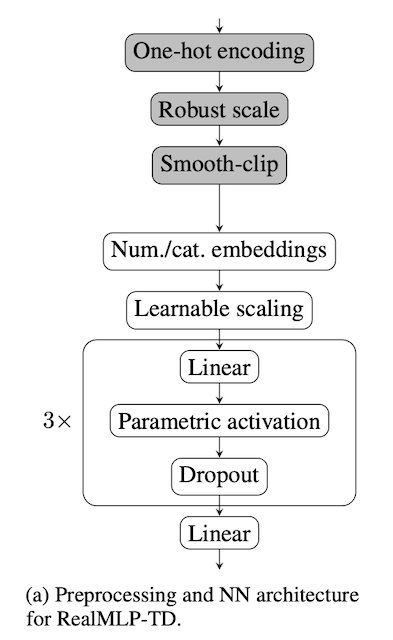

In [7]:
class LearnableScaling(nn.Module):
    """
    Learnable element-wise feature scaling.

    Applies a trainable multiplicative scale to each feature dimension.
    Used to reweight features after embedding and concatenation.
    """
    def __init__(self, dim: int):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        return x * self.scale


class PBLDNumEmbed(nn.Module):

    """
    For each numerical feature x_i, this module produces a 4-dimensional embedding
    Numerical embedding (PBLD-style), per feature x_i:
    phi_i(x_i) = cos(2π * w_i * x_i + b_i)         ∈ R^{K}
    g_i(x_i)   = W2_i * phi_i(x_i) + b2_i          ∈ R^{3}
    e_i(x_i)   = [x_i, g_i(x_i)]                   ∈ R^{4}
    All e_i are concatenated to shape (B, n_features*4).
    """

    def __init__(self, n_features, n_freq=16, sigma=0.01):
        super().__init__()
        self.n_features = n_features
        self.n_freq = n_freq

        # per-feature frequencies + phase
        self.w = nn.Parameter(torch.randn(n_features, n_freq) * sigma)
        self.b = nn.Parameter(torch.zeros(n_features, n_freq))

        # per-feature projection to 3 dims
        self.W2 = nn.Parameter(torch.randn(n_features, 3, n_freq) * sigma)
        self.b2 = nn.Parameter(torch.zeros(n_features, 3))


    @property
    def out_dim(self):
        return self.n_features * 4

    def forward(self, x):
        # x: (B, F)
        x = x.float()
        ang = 2 * math.pi * x.unsqueeze(-1) * self.w.unsqueeze(0) + self.b.unsqueeze(0)
        phi = torch.cos(ang)   # (B, F, K)

        # linear projection per feature
        proj = torch.einsum("bfk,fok->bfo", phi, self.W2) + self.b2  # (B,F,3)

        out = torch.cat([x.unsqueeze(-1), proj], dim=-1)  # (B,F,4)
        return out.reshape(out.size(0), -1)


class NTLinear(nn.Module):

    """
    Neural Tangent Parameterization (NTP) linear layer.

    Forward:
        y = (1 / sqrt(d_in)) * (W x) + b

    Note on initialization:
        The RealMLP-TD paper uses a data-dependent initialization for weights (row-wise rescaling
        based on data statistics) and for biases (he+5 / hull+5).
        Here we keep the NTP forward parameterization, but use standard PyTorch initialization
        (Kaiming-uniform weights and uniform biases) for simplicity.
    """

    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.in_features = in_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features)) if bias else None
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            bound = 1 / math.sqrt(self.in_features) if self.in_features > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        y = F.linear(x, self.weight, None) / math.sqrt(self.in_features)
        if self.bias is not None:
            y = y + self.bias
        return y


class ParametricActivation(nn.Module):

    def __init__(self, dim, act="selu", init_alpha=1.0):
        super().__init__()
        self.alpha = nn.Parameter(torch.full((dim,), init_alpha))

        if act == "selu":
            self.act = nn.SELU()
        elif act == "mish":
            self.act = nn.Mish()
        else:
            raise ValueError(f"Unknown activation: {act}")

    def forward(self, x):
        return (1.0 - self.alpha) * x + self.alpha * self.act(x)




class RealMLP_TD(nn.Module):
    """
    RealMLP-TD: a tabular MLP with structured preprocessing and learnable embeddings.

    Pipeline overview:

    1. Input partitioning
        - Numerical features are processed directly.
        - Categorical features are split into:
            * low-cardinality categories → one-hot encoding
            * high-cardinality categories → embedding layers

    2. Robust preprocessing (numerical + low-card OHE only)
        - Feature-wise median centering
        - Robust scaling using inverse IQR
        - Smooth clipping via x / sqrt(1 + (x / a)^2)

    3. Feature embedding
        - Numerical features are mapped via PBLD-style numerical embeddings
        - High-cardinality categorical features use trainable embeddings
        - All features are concatenated into a single representation

    4. Learnable feature scaling
        - Element-wise trainable rescaling of the full representation

    5. MLP backbone
        - [Linear → ParametricActivation → Dropout] × 3 → Linear → logits

    Instrumentation:
        - Identity-based Capture modules are inserted at key semantic stages
          to expose intermediate representations for analysis (e.g. intrinsic dimension).
    """

    def __init__(
        self,
        num_numerical,
        cat_cardinalities=None,
        max_card=8,
        emb_dim=8,
        dropout=0.15,
        hidden_dim=256,
        num_classes=None,
    ):
        super().__init__()

        self.num_numerical = num_numerical
        self.cat_cardinalities = list(cat_cardinalities) if cat_cardinalities else []
        self.max_card = max_card
        self.emb_dim = emb_dim

        # ----- capture checkpoints -----
        self.capture_input = Capture()
        self.capture_after_ohe = Capture()
        self.capture_after_robust = Capture()
        self.capture_after_embed = Capture()
        self.capture_after_scale = Capture()

        # ----- categorical modules -----
        self.cat_processors = nn.ModuleList()
        self.is_embedding = []

        low_cat_dim = 0
        high_cat_dim = 0
        for card in self.cat_cardinalities:
            if card <= max_card:
                self.cat_processors.append(nn.Identity())
                self.is_embedding.append(False)
                if card == 2:
                    low_cat_dim += 1
                else:
                    low_cat_dim += card
            else:
                emb = nn.Embedding(card+1, emb_dim, padding_idx=0)
                nn.init.normal_(emb.weight, std=0.01)
                with torch.no_grad():
                    emb.weight[0].zero_()
                self.cat_processors.append(emb)
                self.is_embedding.append(True)
                high_cat_dim += emb_dim

        # ----- robust stats only for numerical + low-card one-hot -----
        self.robust_dim = num_numerical + low_cat_dim
        self.register_buffer("median", torch.zeros(1, self.robust_dim))
        self.register_buffer("scale", torch.ones(1, self.robust_dim))
        self.fitted = False

        # ----- numerical embedding -----

        self.num_embedding = PBLDNumEmbed(
            n_features=num_numerical,
        )

        # final input dim after embeddings
        total_input_dim = num_numerical * 4 + low_cat_dim + high_cat_dim

        # ----- learnable scaling -----
        self.learnable_scaling = LearnableScaling(total_input_dim)

        if num_classes is None:
            # regression
            act = "mish"
        else:
            # classification
            act = "selu"

        out_dim = 1 if num_classes is None else num_classes
        # ----- MLP -----
        self.mlp = nn.Sequential(
            NTLinear(total_input_dim, hidden_dim),
            ParametricActivation(hidden_dim, act),
            nn.Dropout(dropout),

            NTLinear(hidden_dim, hidden_dim),
            ParametricActivation(hidden_dim, act),
            nn.Dropout(dropout),

            NTLinear(hidden_dim, hidden_dim),
            ParametricActivation(hidden_dim, act),
            nn.Dropout(dropout),

            NTLinear(hidden_dim, out_dim),
        )

    # ---------- encoders ----------
    def _encode_low(self, x_num, x_cat=None):
        outs = [x_num]
        if x_cat is None or len(self.cat_cardinalities) == 0:
            return torch.cat(outs, dim=1)
        for i, proc in enumerate(self.cat_processors):
            K = self.cat_cardinalities[i]
            if self.is_embedding[i]:
                continue

            col = x_cat[:, i]
            if K == 2:
                # binary -> 1 dim in {-1, +1}, missing -> 0
                # col==0 -> -1, col==1 -> +1, col==-1 -> 0
                out = torch.where(col < 0, torch.zeros_like(col), col * 2 - 1).float().unsqueeze(1)
                outs.append(out)
            else:
                mask = col >= 0
                safe = col.clamp(min=0)
                oh = F.one_hot(safe, num_classes=K).float()
                oh[~mask] = 0.0
                outs.append(oh)
        return torch.cat(outs, dim=1)


    # High-card categorical encoding convention:
    # input indices: -1 for missing, 0..(card-1) for observed categories
    # embedding uses padding_idx=0 for missing => shift observed categories by +1
    def _encode_high(self, x_cat):
        if x_cat is None or len(self.cat_cardinalities) == 0:
            return None

        outs = []
        for i, proc in enumerate(self.cat_processors):
            if self.is_embedding[i]:
                col = x_cat[:, i]
                col = torch.where(col < 0, torch.zeros_like(col), col + 1)
                outs.append(proc(col))
        if len(outs) == 0:
            return None
        return torch.cat(outs, dim=1)

    # ---------- stats ----------
    def fit_statistics(self, x_num, x_cat=None):
        self.eval()
        with torch.no_grad():
            X = self._encode_low(x_num, x_cat)
            median = torch.quantile(X, 0.5, dim=0, keepdim=True)

            q25 = torch.quantile(X, 0.25, dim=0)
            q75 = torch.quantile(X, 0.75, dim=0)
            iqr = q75 - q25

            q0 = torch.quantile(X, 0.0, dim=0)
            q1 = torch.quantile(X, 1.0, dim=0)
            rng = q1 - q0

            scale = torch.zeros_like(iqr)
            mask_iqr = iqr != 0
            scale[mask_iqr] = 1.0 / iqr[mask_iqr]

            mask_rng = (~mask_iqr) & (rng != 0)
            scale[mask_rng] = 2.0 / rng[mask_rng]

            self.median.copy_(median)
            self.scale.copy_(scale.unsqueeze(0))
            self.fitted = True

        self.train()
        print("RealMLP statistics fitted.")

    def _forward_to_mlp_input(self, x_num, x_cat=None):

        if not self.fitted:
            raise RuntimeError("Call fit_statistics(x_num, x_cat) before forward().")

        # collect raw high-card indices for later capture points
        raw_high_cat = None
        if x_cat is not None:
            cols = []
            for i, proc in enumerate(self.cat_processors):
                if self.is_embedding[i]:
                    col = x_cat[:, i]
                    cols.append(col)
            if len(cols) > 0:
                raw_high_cat = torch.stack(cols, dim=1).float()

        # capture: raw input
        _ = self.capture_input(x_num if x_cat is None else torch.cat([x_num, x_cat.float()], dim=1))

        # robust preprocessing on numerical + low-card OHE
        x_low = self._encode_low(x_num, x_cat)
        # capture: after one-hot
        _ = self.capture_after_ohe(x_low if raw_high_cat is None else torch.cat([x_low, raw_high_cat], dim=1))

        # robust preprocessing (median / IQR / smooth clip)
        x_low = (x_low - self.median) * self.scale
        a = 3.0
        x_low = x_low / torch.sqrt(1 + (x_low / a) ** 2)
        # capture: after robust preprocessing
        _ = self.capture_after_robust(x_low if raw_high_cat is None else torch.cat([x_low, raw_high_cat], dim=1))


        x_num_proc = x_low[:, : self.num_numerical]
        x_low_ohe = x_low[:, self.num_numerical :]

        # numerical embedding (PBLD)
        x_num_emb = self.num_embedding(x_num_proc)
        # high-card categorical embedding
        x_high = self._encode_high(x_cat)

        if x_high is None:
            x = torch.cat([x_num_emb, x_low_ohe], dim=1)
        else:
            x = torch.cat([x_num_emb, x_low_ohe, x_high], dim=1)
        # capture: after embedding
        _ = self.capture_after_embed(x)

        # learnable scaling
        x = self.learnable_scaling(x)
        # capture: after scaling
        _ = self.capture_after_scale(x)

        return x


    def forward(self, inputs):

        x_num, x_cat = inputs

        if len(self.cat_cardinalities) == 0 or x_cat.shape[1] == 0:
            x_cat = None

        x = self._forward_to_mlp_input(x_num, x_cat)
        return self.mlp(x)


## 1.3 TabM

TabM is a tabular deep learning architecture proposed in
**“TabM: Advancing Tabular Deep Learning with Parameter-Efficient Ensembling”**
(Gorishniy et al., 2021)

Our implementation follows the original TabM architecture, including the ensemble
dimension handling and initialization scheme, while integrating representation
capture modules for analysis purposes.

Ensemble Dimension Handling
The TabM architecture fundamentally changes the geometry of hidden states by introducing the ensemble dimension (k) in its forward pass. This requires specific handling during ID evaluation, loss calculation, and inference compared to MLPs.

* Dimensionality Transformation for Representation Analysis and Loss

    * The core transformation occurs at the Ensemble View layer, which converts the standard feature vector from B×D to the ensemble tensor B×k×D (Batch, Ensemble Size, Dimension).

    * Hooked Data: The hidden states extracted by the Capture (identity) hook anchors are of shape (B,k,D).

    * ID/Loss Computation: For geometric analysis and loss calculation, this tensor is treated as B×k independent samples. This means the calculation is k times more computationally intensive than for a Standard MLP.

* TabM Training and Inference Logic

    The presence of the k dimension necessitates two distinct logical paths during training:

    * Loss Calculation (Training Objective)

        * The objective is to minimize the error across all k parallel ensemble members.

        * The outputs (shape [B,k,C]) are flattened to outputs_flat (shape [B×k,C]).

        * The targets y (shape B) are repeated k times to y_flat (shape [B×k,1]).

        * The loss is computed over all B×k effective samples: Loss=criterion(outputs_flat, y_flat).

    * Accuracy Calculation (Inference Objective)

        * Inference uses the wisdom of the crowds from the ensemble, requiring an average over the k members.

        * The logits of the k members are averaged across the k dimension (dim=1) to form the ensemble logits (ensemble_logits, shape [B,C]).

        * The final prediction is derived from this averaged tensor: Preds = argmax(ensemble_logits).

In [8]:
class TabM(nn.Module):

    """
    Initializes the TabM model, which uses the BatchEnsemble technique to run k
    ensemble members simultaneously via shared weights and per-member (R,S,B) adapters..

    Preprocessing Pipeline:
        1. Feature Encoding: Numerical features are used directly; Categorical features are mapped via Embeddings.
        2. Concatenation: Joins numerical features with all categorical Embeddings to form the backbone input.
    Main Backbone Network:
        Architecture:
        [LinearBatchEnsemble -> ReLU -> Dropout] x n_blocks -> LinearEnsemble -> Logits((B, k, C))

        Architecture Note:
            The EnsembleView layer expands the input to (Batch, k, D), In the first BatchEnsemble layer,
            only the input scaling R is initialized with random signs; S is set to ones. All subsequent layers
            initialize R and S to ones, bias B is zero-initialized.

            Capture (identity) modules are inserted as hook anchors for representation analysis.
    """

    def __init__(self, num_numerical, cat_cardinalities,
                 d_block=512, num_classes=None, n_blocks=3, k=16, dropout=0.1, emb_dim=8):


        """
        Args:
            k (int): The number of ensemble members (Ensemble Size).
                    Paper uses k=32; we use a smaller k for ID measurements
            d_block (int): Dimensionality of each MLP block.
            n_blocks (int): The number of MLP blocks.
            num_classes (int): The number of output classes.
            (Other standard args omitted for brevity)
        """

        super().__init__()

        # ----- capture checkpoints -----
        self.capture_input = Capture()
        self.capture_after_preprocess = Capture()
        self.cat_cardinalities = cat_cardinalities


        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(c+1, emb_dim, padding_idx=0) for c in self.cat_cardinalities
        ])

        for emb in self.cat_embeddings:
            with torch.no_grad():
                emb.weight[0].zero_()

        backbone_input_dim = num_numerical + len(self.cat_cardinalities) * emb_dim

        out_dim = 1 if num_classes is None else num_classes

        layers = []
        # --- 1. Ensemble View Layer (Core) ---
        layers.append(tabm.EnsembleView(k=k))
        # --- 2. TabM Blocks ---
        # initialize all multiplicative adapters R and S, except for the very first R, deterministically with 1
        for i in range(n_blocks):
            current_in = backbone_input_dim if i == 0 else d_block
            scaling_init = ('random-signs', 'ones') if i == 0 else ('ones', 'ones')

            be_layer = tabm.LinearBatchEnsemble(
                in_features=current_in,
                out_features=d_block,
                k=k,
                bias=True,
                scaling_init=scaling_init,
            )
            # B = 0
            if be_layer.bias is not None:
                with torch.no_grad():
                    be_layer.bias.zero_()

            layers.extend([
                be_layer,
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
        # --- 3. Final Output Layer ---
        layers.append(tabm.LinearEnsemble(in_features=d_block, out_features=out_dim, k=k))

        self.ensemble_mlp = nn.Sequential(*layers)

    def forward(self, inputs):

        x_num, x_cat = inputs

        if len(self.cat_cardinalities) == 0 or x_cat.shape[1] == 0:
            x_cat = None

        _ = self.capture_input(x_num if x_cat is None else torch.cat([x_num, x_cat.float()], dim=1))

        emb_outs = []
        if x_cat is not None:
            for i, emb in enumerate(self.cat_embeddings):
                col = x_cat[:, i]
                col = torch.where(col < 0, torch.zeros_like(col), col + 1)
                emb_outs.append(emb(col))

        x = torch.cat([x_num] + emb_outs, dim=1)
        _ = self.capture_after_preprocess(x)

        return self.ensemble_mlp(x)

## 2. Utilities and Data Setup
This section contains helper functions essential for setting up the experiment: defining how model depth is tracked for intrinsic dimension (ID) analysis, and orchestrating the initial preprocessing and loading of raw tabular data.

In [9]:
def getDepths_RealMLP_TD(model):
    modules = []
    names = []
    depths = []

    # ---- Capture checkpoints (in a fixed semantic order) ----
    cap_list = [
        ("input", model.capture_input),
        ("one-hot\nencoding", model.capture_after_ohe),
        ("scale\nclip", model.capture_after_robust),
        ("num/cat\nembeddings", model.capture_after_embed),
        ("learnable\nscaling", model.capture_after_scale),
    ]
    for i, (n, m) in enumerate(cap_list):
        modules.append(m)
        names.append(n)
        depths.append(i)

    # ---- MLP linear layers (4 linears) ----
    linear_layers = [layer for layer in model.mlp if isinstance(layer, NTLinear)]
    for j, layer in enumerate(linear_layers):
        modules.append(layer)
        names.append("out" if j == len(linear_layers) - 1 else f"fc{j+1}")
        depths.append(len(depths))

    return modules, names, np.array(depths)


def getDepths_StandardMLP(model):
    modules = []
    names = []
    depths = []

    # ---- Capture checkpoints (in a fixed semantic order) ----
    cap_list = [
        ("input", model.capture_input),
        ("preprocessing", model.capture_after_preprocess),
    ]
    for i, (n, m) in enumerate(cap_list):
        modules.append(m)
        names.append(n)
        depths.append(i)

    # ---- MLP linear layers (4 linears) ----
    linear_layers = [layer for layer in model.mlp if isinstance(layer, nn.Linear)]
    for j, layer in enumerate(linear_layers):
        modules.append(layer)
        names.append("out" if j == len(linear_layers) - 1 else f"fc{j+1}")
        depths.append(len(depths))

    return modules, names, np.array(depths)



def getDepths_TabM(model):
    modules = []
    names = []
    depths = []

    # 1) Capture checkpoints
    cap_list = [
        ("input", model.capture_input),
        ("preprocessing", model.capture_after_preprocess),
    ]
    for n, m in cap_list:
        modules.append(m)
        names.append(n)
        depths.append(len(depths))

    # 2) BatchEnsemble blocks + final ensemble head
    #    Keep order as in model.ensemble_mlp (Sequential)
    for layer in model.ensemble_mlp:
        cls_name = layer.__class__.__name__
        if cls_name in ("LinearBatchEnsemble", "LinearEnsemble"):
            modules.append(layer)
            if cls_name == "LinearEnsemble":
                names.append("out")
            else:
                # count fc blocks in the order they appear
                names.append(f"be_fc{sum(1 for x in names if x.startswith('be_fc')) + 1}")
            depths.append(len(depths))

    return modules, names, np.array(depths)

In [10]:
class TabularPairDataset(Dataset):
    def __init__(self, x_num, x_cat, y):
        self.x_num = x_num
        self.x_cat = x_cat
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return (self.x_num[idx], self.x_cat[idx]), self.y[idx]

class TabularEncoder:
    def __init__(self):
        self.num_cols = None
        self.cat_cols = None

        self.num_fill = {}          # col -> fill_value (fit on train)
        self.cat_maps = {}          # col -> dict(value_str -> index)
        self.cat_cardinalities = [] # cardinality = number of non-missing categories (train-only)

        self._is_fitted = False

    def fit(self, X: pd.DataFrame):
        # Identify column types from training data
        self.num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

        # Numerical fill values (train-only)
        self.num_fill = {}
        for col in self.num_cols:
            s = X[col]
            fill_value = s.median(skipna=True)
            if pd.isna(fill_value):
                fill_value = 0.0
            self.num_fill[col] = float(fill_value)

        # 3 Categorical mapping (train-only), missing excluded from distinct values
        self.cat_maps = {}
        self.cat_cardinalities = []
        for col in self.cat_cols:
            s = X[col]
            non_missing = s[s.notna()].astype(str)
            categories = sorted(non_missing.unique().tolist())  # distinct values, no missing
            mapping = {v: i for i, v in enumerate(categories)}

            self.cat_maps[col] = mapping
            self.cat_cardinalities.append(len(categories))

        self._is_fitted = True
        return self

    def transform(self, X: pd.DataFrame):

        # Categorical encoding:
        # - Known categories (seen in training) -> indices 0 .. K-1
        # - Missing values -> -1
        # - OOV values (unseen at test time) -> -1, it will be handled explicitly inside the model

        if not self._is_fitted:
            raise RuntimeError("Call fit(X_train) before transform().")

        # Numerical
        X_num_df = X[self.num_cols].copy()
        for col in self.num_cols:
            X_num_df[col] = X_num_df[col].fillna(self.num_fill[col])

        # Categorical: missing -> -1; OOV -> -1
        X_cat_df = X[self.cat_cols].copy()
        for col in self.cat_cols:
            mapping = self.cat_maps[col]
            col_data = X_cat_df[col]

            # map known values; unknown and missing become NaN then fill -1
            encoded = col_data.astype(str).map(mapping)
            encoded = encoded.where(col_data.notna(), np.nan)   # keep missing as NaN
            encoded = encoded.fillna(-1).astype(int)

            X_cat_df[col] = encoded

        X_num = torch.tensor(X_num_df.to_numpy(), dtype=torch.float32)
        X_cat = torch.tensor(X_cat_df.to_numpy(), dtype=torch.long)
        return X_num, X_cat

    def fit_transform(self, X: pd.DataFrame):
        return self.fit(X).transform(X)


def make_dataloaders(data, num_train, num_test, seed):
    X = data.data
    y = data.target

    rng = np.random.RandomState(seed)
    indices = np.arange(len(X))
    rng.shuffle(indices)

    train_idx = indices[:num_train]
    test_idx = indices[num_train:num_train+num_test]

    X_train_df = X.iloc[train_idx]
    X_test_df  = X.iloc[test_idx]

    # 1) Fit encoder on TRAIN only
    enc = TabularEncoder().fit(X_train_df)

    # 2) Transform both with same encoder
    X_train_num, X_train_cat = enc.transform(X_train_df)
    X_test_num,  X_test_cat  = enc.transform(X_test_df)

    # y encoding
    y = y.astype(str)
    classes = sorted(y.unique())
    mapping = {cls: i for i, cls in enumerate(classes)}
    y_all = y.map(mapping).to_numpy(dtype="int64")

    y_train = torch.tensor(y_all[train_idx], dtype=torch.long)
    y_test  = torch.tensor(y_all[test_idx], dtype=torch.long)

    train_ds = TabularPairDataset(X_train_num, X_train_cat, y_train)
    test_ds  = TabularPairDataset(X_test_num, X_test_cat, y_test)

    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

    return train_loader, test_loader, X_train_num.shape[1], enc.cat_cardinalities

# 3. Full Experiment: Training and Intrinsic Dimension Analysis on the Adult Dataset
This series of code cells orchestrates the entire experiment: from data loading and model initialization to training both the RealMLP and StandardMLP architectures on the Adult income classification dataset, culminating in a detailed analysis of the Intrinsic Dimension (ID) dynamics across epochs and model layers. The ID is measured using the TwoNN method.

In [11]:
# --- Configuration Parameters ---
num_train = 20000
num_test = 2000
depth_fns = {"RealMLP":getDepths_RealMLP_TD,
             "StandardMLP":getDepths_StandardMLP,
             "TabM":getDepths_TabM
             }
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
estimator = {"TwoNN": partial(twonn_id,device=device,batch=512)}
criterion = nn.CrossEntropyLoss()
metrics = accuracy_sum
adult = fetch_openml(data_id=1590, as_frame=True)
adult_train,adult_test, adult_num_numerical, adult_cardinality = make_dataloaders(adult,num_train,num_test,seed=42)

RealMLP_adult={"RealMLP":RealMLP_TD(adult_num_numerical,adult_cardinality,num_classes=2)}
RealMLP_adult["RealMLP"].fit_statistics(
    adult_train.dataset.x_num,
    adult_train.dataset.x_cat
)

StandardMLP_adult={"StandardMLP":StandardMLP(adult_num_numerical,adult_cardinality,num_classes=2)}
StandardMLP_adult["StandardMLP"].fit_statistics(adult_train.dataset.x_num)

RealMLP statistics fitted.
StandardMLP Statistics Fitted!


## 3.1 ID Measurement of Untrained Models

Models: 100%|██████████| 1/1 [00:00<00:00,  3.72it/s]


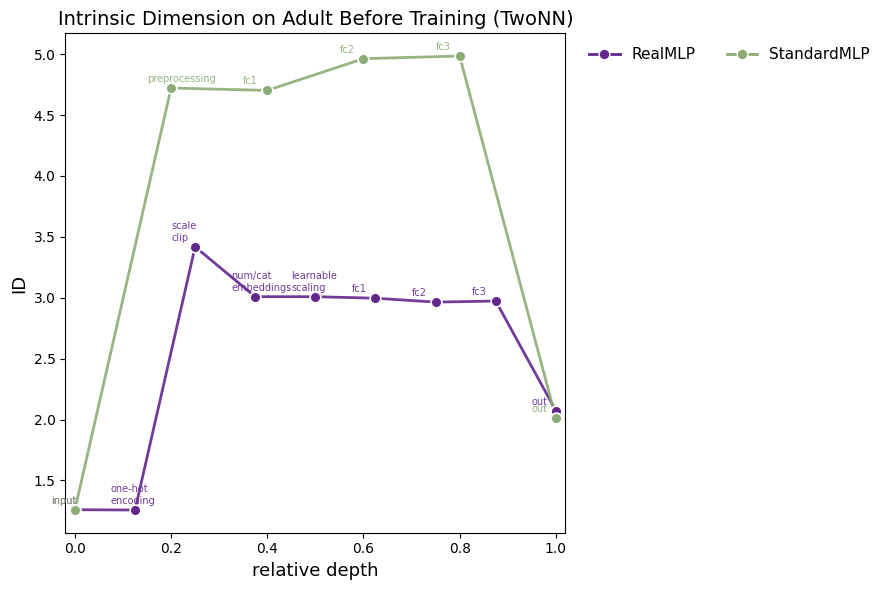

In [ ]:
id_dynamics_realmlp_untrained = compute_id_dynamics_across_models(
      RealMLP_adult,
      estimator,
      adult_test,
      depth_fns,
      device,
      pca_dim=False)

id_dynamics_standardmlp_untrained = compute_id_dynamics_across_models(
      StandardMLP_adult,
      estimator,
      adult_test,
      depth_fns,
      device,
      pca_dim=False)

id_dynamics_untrained = {**id_dynamics_realmlp_untrained,
                         **id_dynamics_standardmlp_untrained}

title = "Intrinsic Dimension on Adult Before Training (TwoNN)"
plot_fig3b(id_dynamics_untrained,"TwoNN",title,annotate=True)

## 3.2 Evaluation of **RealMLP** on **Adult**

Training epochs: 100%|██████████| 15/15 [00:33<00:00,  2.22s/it]


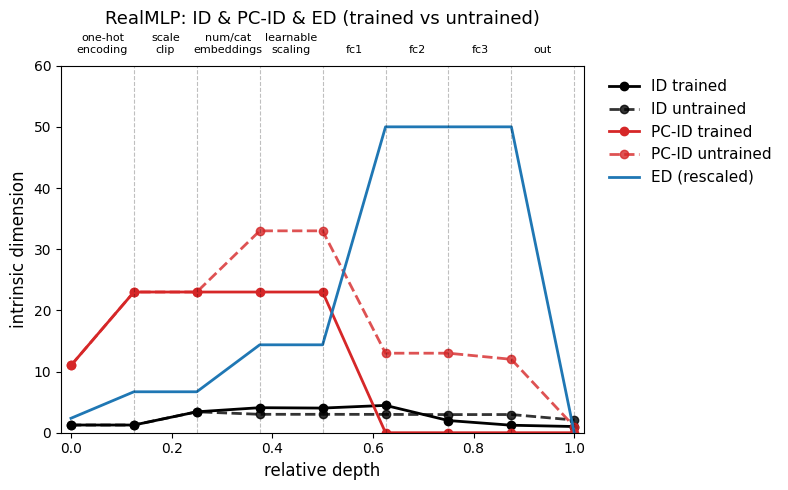

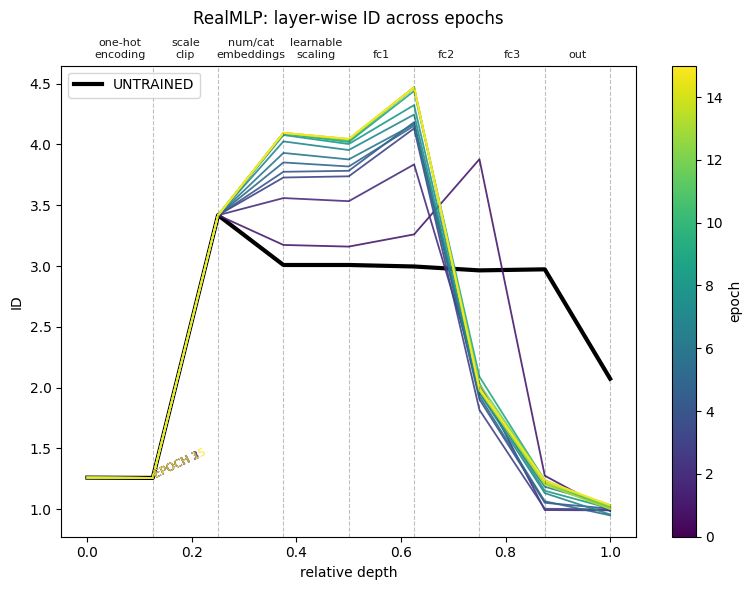

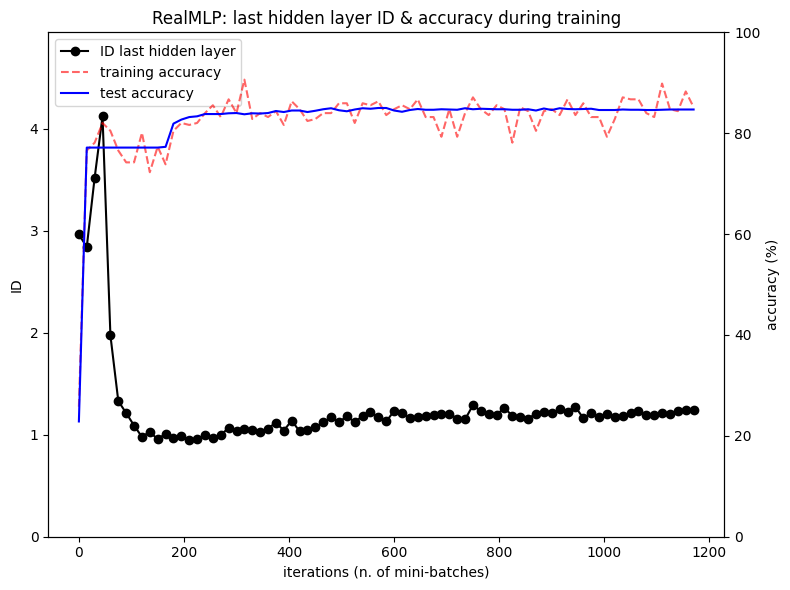

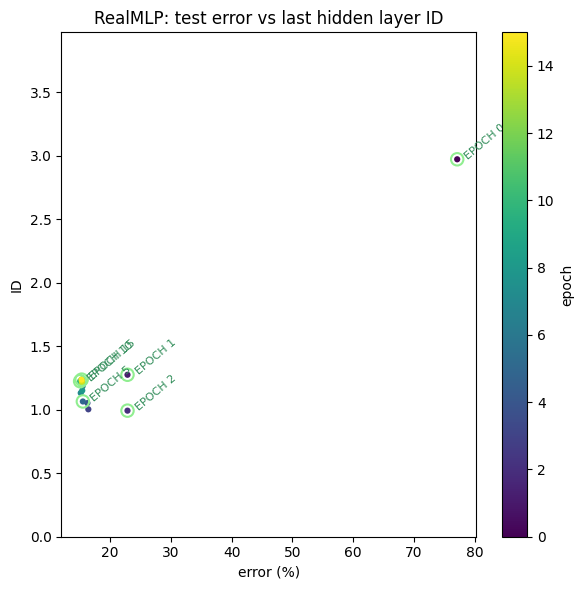

In [ ]:
# --- RealMLP Optimizer and Scheduler Setup ---
epochs = 15
id_logging_interval = 15
(model_name, net), = RealMLP_adult.items()
total_steps = epochs * len(adult_train)
optimizer = torch.optim.Adam(
    net.parameters(),
    lr=1e-3,
    betas=(0.9, 0.95),
    eps=1e-8,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

# --- Run Training and ID Computation ---
depths, result_per_batch, result_per_epoch, result_0_and_best_epoch,RealMLP_adult_best = \
    train_and_compute_id(
        epochs,
        RealMLP_adult,
        adult_train,
        adult_test,
        estimator,
        criterion,
        metrics,
        optimizer,
        id_logging_interval,
        device=device,
        batch_scheduler=scheduler,
        depth_fns=depth_fns
    )

# --- Visualize Results ---
plot_fig5c(model_name, result_0_and_best_epoch, depths,50,title=f"{model_name}: ID & PC-ID & ED (trained vs untrained)",annotate=True)
plot_fig9A(result_per_epoch, depths,title=f"{model_name}: layer-wise ID across epochs",annotate=True)
plot_fig9B(result_per_batch,title=f"{model_name}: last hidden layer ID & accuracy during training")
plot_fig9C(result_per_epoch,title=f"{model_name}: test error vs last hidden layer ID")


### Observations: RealMLP Training Dynamics

The visualizations above provide strong evidence for the "Compression" hypothesis in deep learning:

* **Fig 1 (Trained vs. Untrained):** The solid black line (Trained ID) ends lower than the dashed line (Untrained ID). This confirms that the optimization process has actively compressed the data representation into a lower-dimensional manifold.
* **Fig 2 (Layer-wise Evolution):** RealMLP exhibits a clear expansion–compression pattern in intrinsic dimension. The ID peaks at the first trainable representation stage and then decreases monotonically across the MLP layers, with progressively stronger compression as training proceeds. Fixed preprocessing stages show identical IDs across epochs, reflecting their non-trainable nature.
* **Fig 3 (ID vs. Accuracy):** There is a visible correlation: as Test Accuracy (Blue) improves and stabilizes, the Intrinsic Dimension of the last hidden layer (Black) trends downward. This suggests that learning involves finding a simpler geometric representation of the data.
* **Fig 4 (Error vs. ID):** The training trajectory moves towards the bottom-left corner, showing that the model minimizes both prediction error and the geometric complexity of its representation simultaneously.

## 3.3 Evaluation of **StandardMLP** on **Adult**

Training epochs: 100%|██████████| 15/15 [00:23<00:00,  1.55s/it]


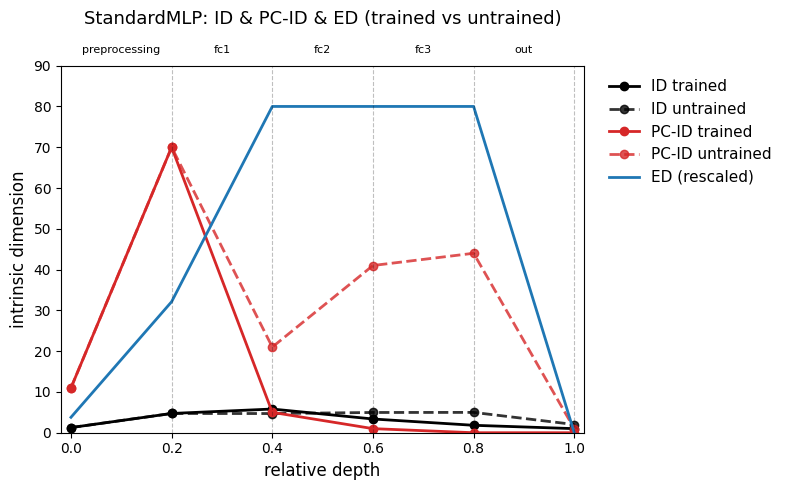

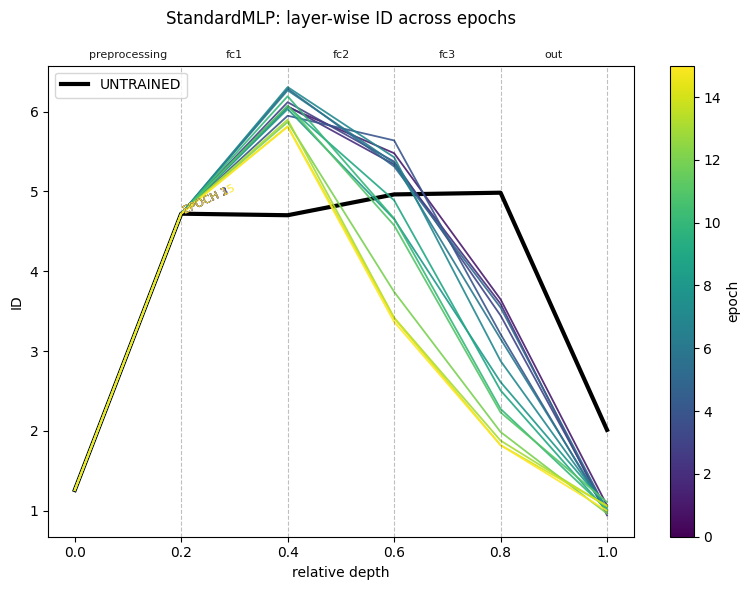

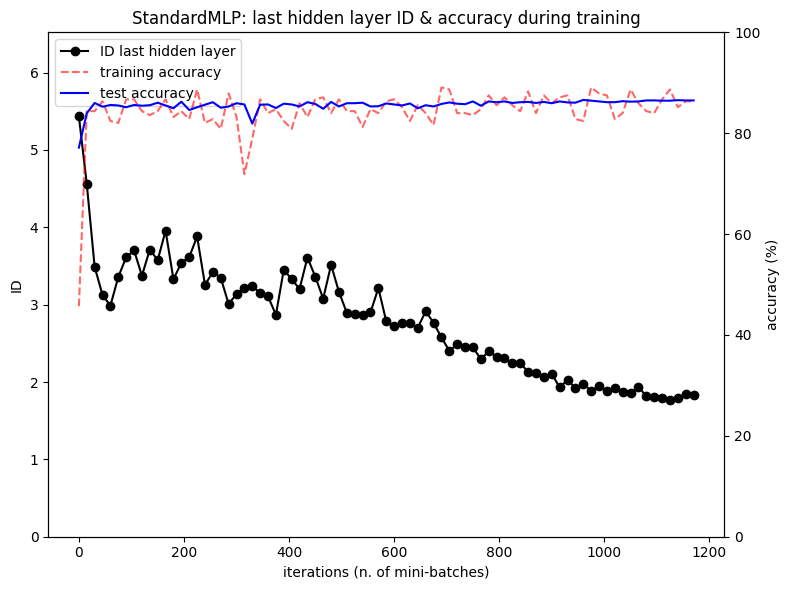

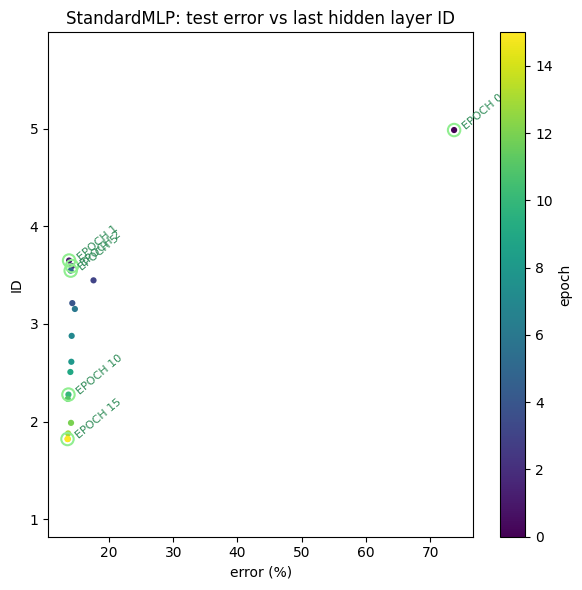

In [ ]:
(model_name, net), = StandardMLP_adult.items()
# total_steps = epochs * len(adult_train)
optimizer = torch.optim.Adam(
    net.parameters(),
    lr=1e-2,
    betas=(0.9, 0.95),
    eps=1e-8,
    weight_decay=1e-2,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

depths, result_per_batch, result_per_epoch, result_0_and_best_epoch, StandardMLP_adult_best = \
    train_and_compute_id(
        epochs,
        StandardMLP_adult,
        adult_train,
        adult_test,
        estimator,
        criterion,
        metrics,
        optimizer,
        id_logging_interval,
        device=device,
        batch_scheduler=scheduler,
        depth_fns=depth_fns
    )

plot_fig5c(model_name, result_0_and_best_epoch, depths,80,title=f"{model_name}: ID & PC-ID & ED (trained vs untrained)",annotate=True)
plot_fig9A(result_per_epoch, depths,title=f"{model_name}: layer-wise ID across epochs",annotate=True)
plot_fig9B(result_per_batch,title=f"{model_name}: last hidden layer ID & accuracy during training")
plot_fig9C(result_per_epoch,title=f"{model_name}: test error vs last hidden layer ID")


### Observations: StandardMLP Training Dynamics

Comparing these results with the RealMLP metrics above reveals distinct structural differences:

* **Fig 2 (Pronounced Expansion):** Unlike the stable profile of RealMLP, the Standard MLP shows a sharp "Expansion" phase in the first layer (ID spikes to >6.0). The network drastically increases dimensionality before compressing it, a characteristic behavior of ReLU networks.
* **Fig 3 & 4 :** The model then exhibits a continuous and exceptionally smooth, monotonic descent throughout the entire training duration. The training trajectory demonstrates a clear movement from the initial high-ID, high-error regime (Epoch 0) toward the bottom-left corner (low error, low ID).

## 3.4 ID Measurement of Trained Models

Models: 100%|██████████| 1/1 [00:00<00:00,  7.75it/s]


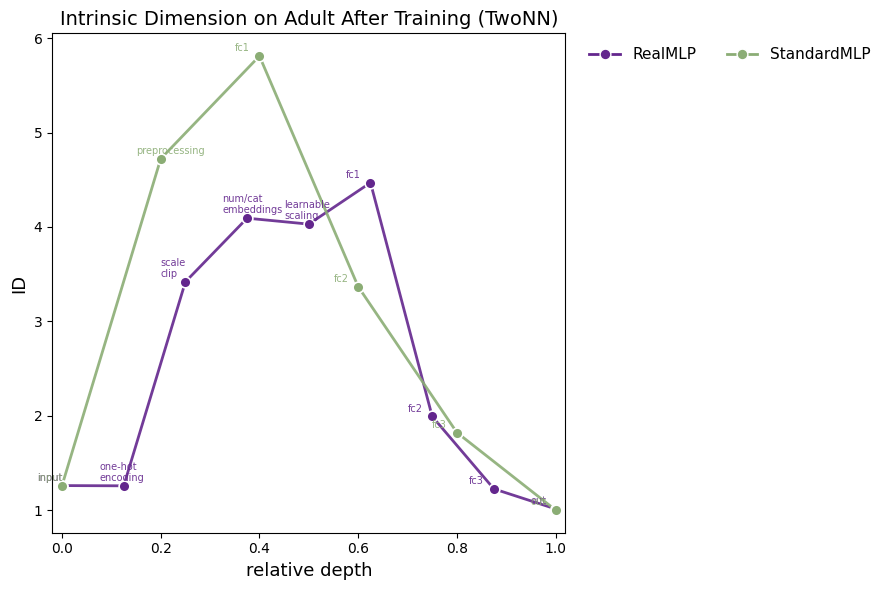

In [ ]:
id_dynamics_realmlp_trained = compute_id_dynamics_across_models(
      RealMLP_adult_best,
      estimator,
      adult_test,
      depth_fns,
      device,
      pca_dim=False)

id_dynamics_standardmlp_trained = compute_id_dynamics_across_models(
      StandardMLP_adult_best,
      estimator,
      adult_test,
      depth_fns,
      device,
      pca_dim=False)

id_dynamics_trained = {**id_dynamics_realmlp_trained,
                       **id_dynamics_standardmlp_trained}

title = "Intrinsic Dimension on Adult After Training (TwoNN)"
plot_fig3b(id_dynamics_trained,"TwoNN",title,annotate=True)

### Observations: Comparative ID Dynamics (Trained State)

After training, both models exhibit a characteristic expansion–contraction trajectory along the representation pipeline. The intrinsic dimension increases during the feature lifting stage, where raw tabular inputs are mapped into a higher-dimensional learned space, and subsequently decreases as representations propagate through the MLP blocks toward the output layer.

However, the two architectures differ markedly in how this geometric evolution unfolds.

StandardMLP undergoes substantially stronger dimensional expansion, reaching a higher peak intrinsic dimension and maintaining high-dimensional representations deeper into the network before contracting. This behavior suggests a reliance on late-stage compression to shape task-relevant features.

In contrast, RealMLP exhibits a more controlled expansion followed by earlier contraction, indicating that its architecture imposes stronger geometric constraints on the learned representations. Such early regularization may reduce redundant feature mixing and promote more efficient representations.

Despite these differences, both models ultimately converge to similarly low intrinsic dimensions at the output layer, consistent with the low-dimensional structure required for classification.


## 4. Generalization Analysis: Diverse Datasets

To validate the universality of our findings, we extend the analysis to additional datasets with varying characteristics (e.g., higher complexity, multi-class targets).

We define a reusable evaluation pipeline `report_id_statistics` that:
1.  Computes the Untrained ID profile.
2.  Trains the model while tracking ID dynamics.
3.  Visualizes the training trajectory (Layer-wise ID, Accuracy vs ID).
4.  Compares the final Trained ID profile against the initialization.

Building on the reusable analysis routine `report_id_statistics`, we further implement a higher-level evaluation wrapper `evaluate_model_on_data` to facilitate systematic experimentation across diverse tabular datasets and model architectures.

This wrapper standardizes dataset loading, model instantiation, and optimization settings, enabling consistent and comparable intrinsic dimension analysis across datasets with different feature structures and label cardinalities.

In [ ]:
def report_id_statistics(model, num_classes, estimator, train_loader, test_loader, data_name,
                         depth_fns, epochs, optimizer, criterion, metrics, id_logging_interval,
                         device, epoch_scheduler=None, batch_scheduler=None,y_lim=50,
                         show=True,savepath=None):

    (model_name, net), = model.items()
    print(f"--- Starting Analysis for {model_name} on {data_name} ---")

    id_dynamics_untrained = compute_id_dynamics_across_models(
        model,
        estimator,
        test_loader,
        depth_fns,
        device,
        pca_dim=False)
    k, v = id_dynamics_untrained.popitem()
    id_dynamics_untrained[k+'_before'] = v

    depths, result_per_batch, result_per_epoch, result_0_and_best_epoch, model_best = \
        train_and_compute_id(
            epochs,
            model,
            train_loader,
            test_loader,
            estimator,
            criterion,
            metrics,
            optimizer,
            id_logging_interval,
            device=device,
            batch_scheduler=batch_scheduler,
            epoch_scheduler=epoch_scheduler,
            depth_fns=depth_fns
        )

    plot_fig5c(model_name, result_0_and_best_epoch,
               depths,y_lim,title=f"{model_name}: ID & PC-ID & ED (trained vs untrained)",
               annotate=True,
               show=show,
               savepath=savepath)
    plot_fig9A(result_per_epoch, depths,
               title=f"{model_name}: layer-wise ID across epochs",
               annotate=True,
               show=show,
               savepath=savepath)
    
    # Use task-specific plotting: regression vs classification
    if num_classes is None:
        plot_fig9B_regression(result_per_batch,
               title=f"{model_name}: last hidden layer ID & regression metric during training",
               show=show,
               savepath=savepath)
        plot_fig9C_regression(result_per_epoch,
               title=f"{model_name}: test regression metric vs last hidden layer ID",
               show=show,
               savepath=savepath)
    else:
        plot_fig9B(result_per_batch,
                title=f"{model_name}: last hidden layer ID & accuracy during training",
                show=show,
                savepath=savepath)
        plot_fig9C(result_per_epoch,
                title=f"{model_name}: test error vs last hidden layer ID",
                show=show,
                savepath=savepath)

    id_dynamics_trained = compute_id_dynamics_across_models(
        model_best,
        estimator,
        test_loader,
        depth_fns,
        device,
        pca_dim=False)

    k, v = id_dynamics_trained.popitem()
    id_dynamics_trained[k+'_after'] = v

    id_dynamics = {**id_dynamics_untrained,
                   **id_dynamics_trained}
    title = (
    f"Intrinsic Dimension on {data_name} "
    f"({model_name}) Before and After Training (TwoNN)"
    )
    plot_fig3b(id_dynamics,"TwoNN",title,annotate=True,show=show,savepath=savepath)

In [13]:
MODELS = {
    "RealMLP": lambda n_num, cat_card, num_classes: RealMLP_TD(n_num, cat_card, num_classes=num_classes),
    "StandardMLP": lambda n_num, cat_card, num_classes: StandardMLP(n_num, cat_card, num_classes=num_classes),
    "TabM": lambda n_num, cat_card, k, num_classes: TabM(n_num, cat_card, k=k, num_classes=num_classes),
}



depth_fns = {"RealMLP":getDepths_RealMLP_TD,
             "StandardMLP":getDepths_StandardMLP,
             "TabM":getDepths_TabM
             }


def evaluate_model_on_data(data_id, model_name, opt_lr, opt_wd,num_classes=None, num_train=20000, num_test=2000,
                           epochs=15, id_logging_interval=15, estimator=None,
                           depth_fns=depth_fns, device=None, criterion=None, metrics=None,
                           y_lim=50,k=10, savepath=None, show=True):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if estimator is None:
        estimator = {"TwoNN": partial(twonn_id, device=device, batch=512)}

    data = fetch_openml(data_id=data_id, as_frame=True)
    data_name = data.details.get("name", f"openml_{data_id}")
    train_loader, test_loader, num_numerical, cardinality = make_dataloaders(data, num_train, num_test, seed=42)
    if model_name == "RealMLP":
        model = {model_name: MODELS[model_name](num_numerical, cardinality, num_classes)}
        model[model_name].fit_statistics(
            train_loader.dataset.x_num,
            train_loader.dataset.x_cat
        )
    elif model_name == "StandardMLP":
        model = {model_name: MODELS[model_name](num_numerical, cardinality, num_classes)}
        model[model_name].fit_statistics(train_loader.dataset.x_num)
    elif model_name == "TabM":
        model = {model_name: MODELS[model_name](num_numerical, cardinality, k, num_classes)}
    else:
        raise ValueError(f"Unknown model_name: {model_name}. Choose from {list(MODELS.keys())}")

    total_steps = epochs * len(train_loader)
    (model_name, net), = model.items()

    if criterion is None:
        if model_name == "TabM":
            if num_classes is None:
                criterion = regress_mse_ensemble_sum
            else:
                criterion = classif_ce_ensemble_sum
        else:
            if num_classes is None:
                criterion = regress_mse_sum
            else:
                criterion = torch.nn.CrossEntropyLoss(reduction="sum")
    if metrics is None:
        if model_name == "TabM":
            if num_classes is None:
                metrics = regress_mse_ensemble_sum
            else:
                metrics = classif_accuracy_ensemble_sum
        else:
            if num_classes is None:
                metrics = regress_mse_sum
            else:
                metrics = accuracy_sum

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=opt_lr,
        betas=(0.9, 0.95),
        eps=1e-8,
        weight_decay=opt_wd,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

    report_id_statistics(
        model,
        num_classes,
        estimator,
        train_loader,
        test_loader,
        data_name,
        depth_fns,
        epochs,
        optimizer,
        criterion,
        metrics,
        id_logging_interval,
        device,
        batch_scheduler=scheduler,
        y_lim=y_lim,
        show=show,
        savepath=savepath
    )



## 4.1 Experiment: Covertype (Multi-class)

### 4.1.1 Evaluation of **TabM** on **Forest Covertype**



--- Starting Analysis for TabM on covertype ---


Training epochs: 100%|██████████| 15/15 [02:22<00:00,  9.53s/it]


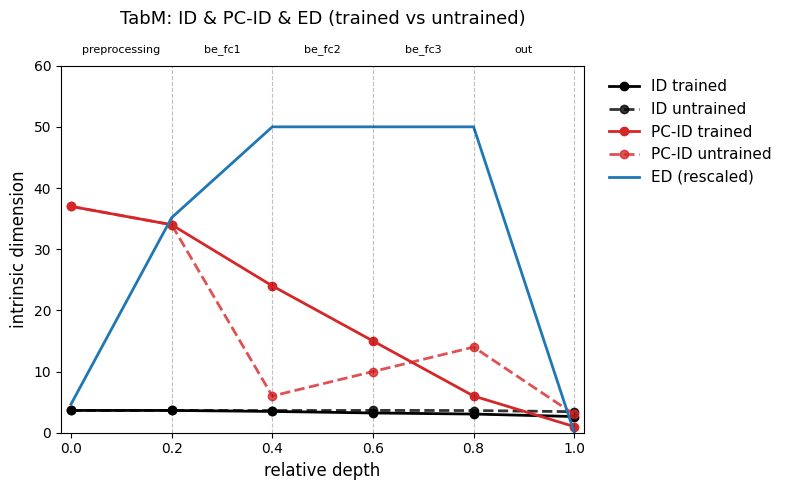

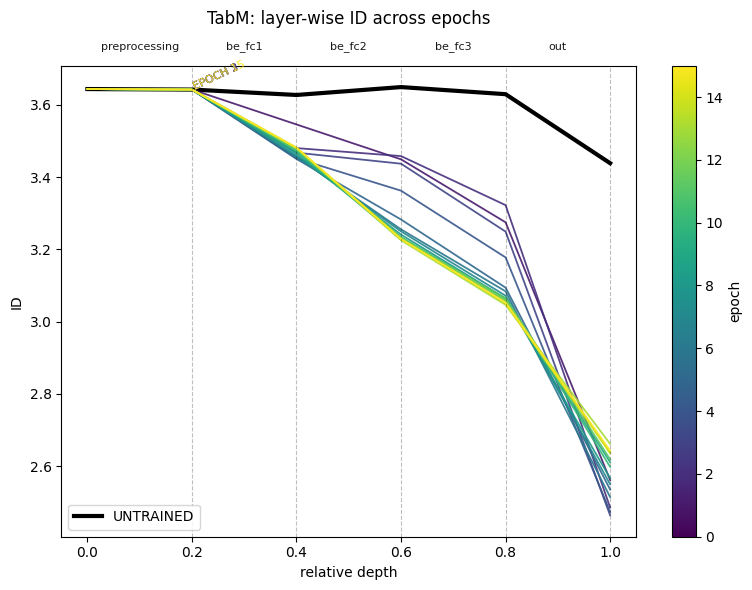

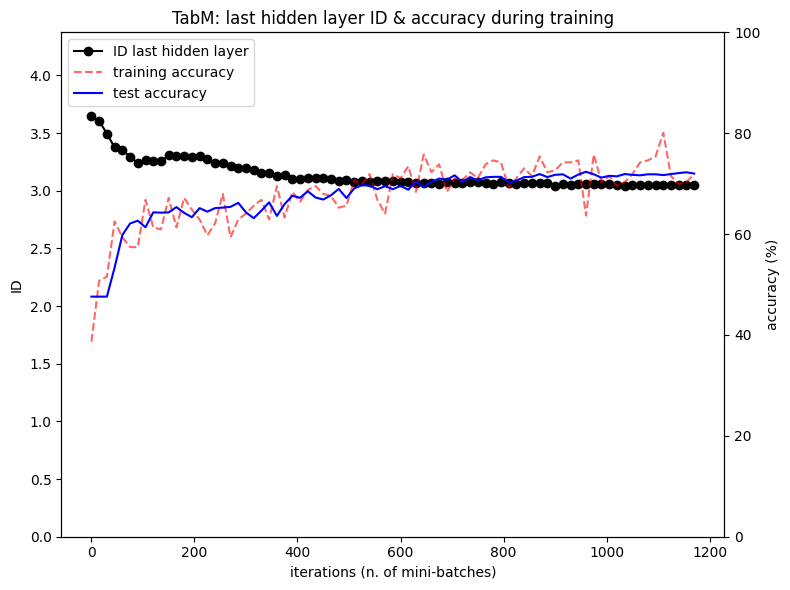

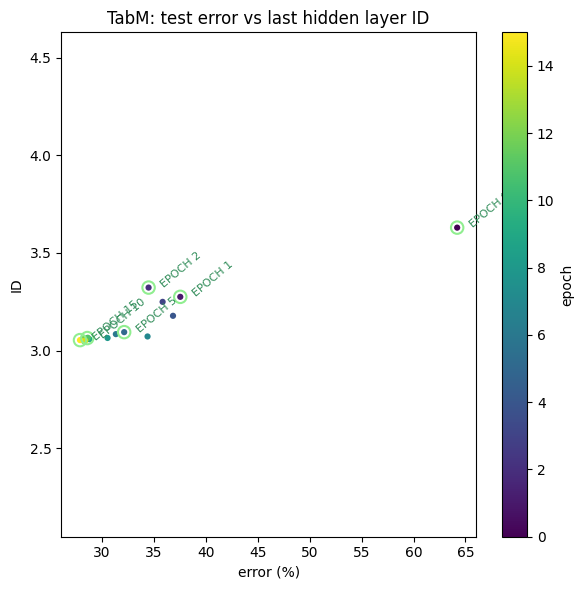

Models: 100%|██████████| 1/1 [00:02<00:00,  2.78s/it]


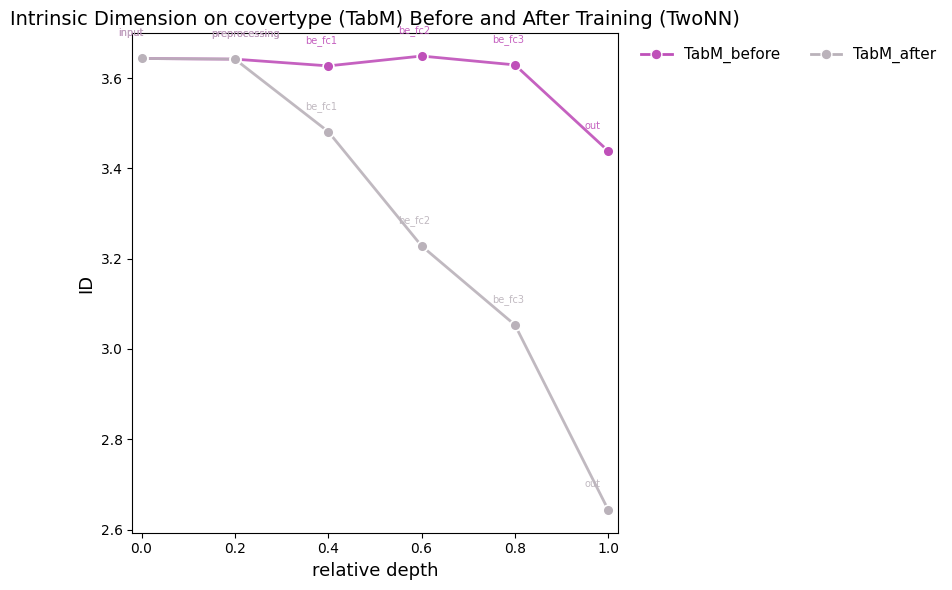

In [ ]:
evaluate_model_on_data(data_id=150,model_name="TabM",
                       opt_lr=1e-3,opt_wd=1e-4,num_classes=7,k=6,)

### 4.1.2 Evaluation of **RealMLP** on **Forest Covertype**

RealMLP statistics fitted.
--- Starting Analysis for RealMLP on covertype ---


Training epochs: 100%|██████████| 15/15 [00:46<00:00,  3.09s/it]


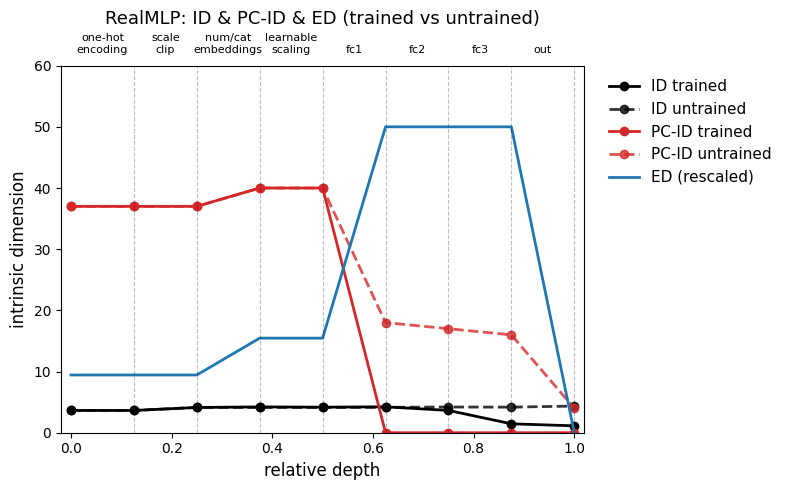

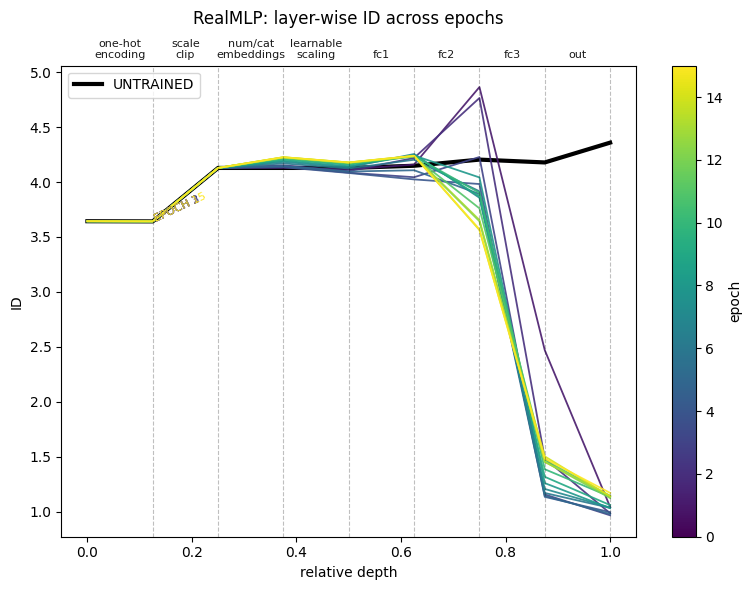

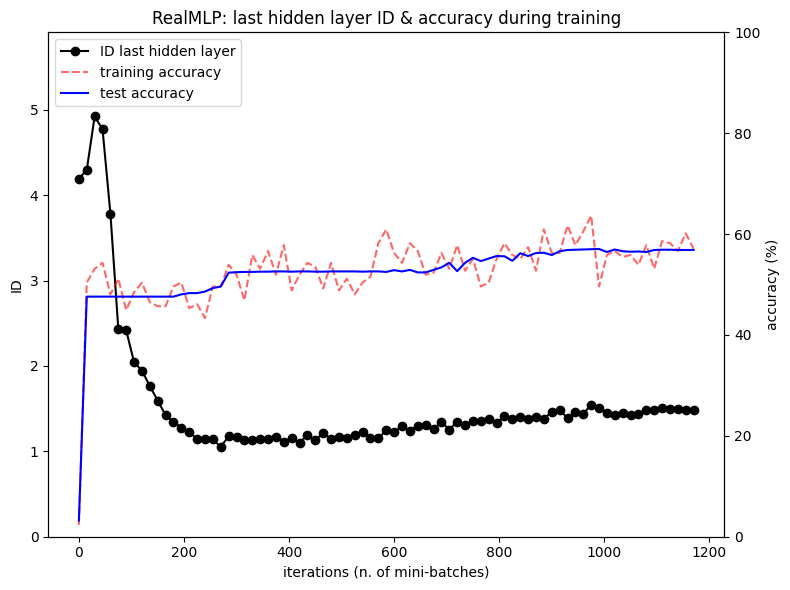

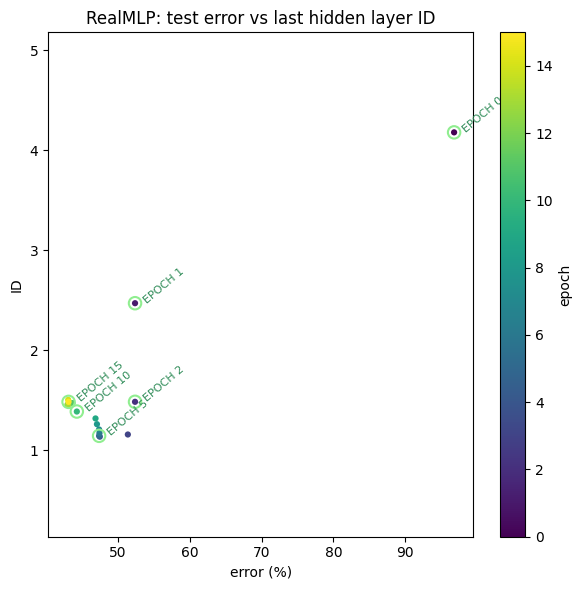

Models: 100%|██████████| 1/1 [00:00<00:00,  4.35it/s]


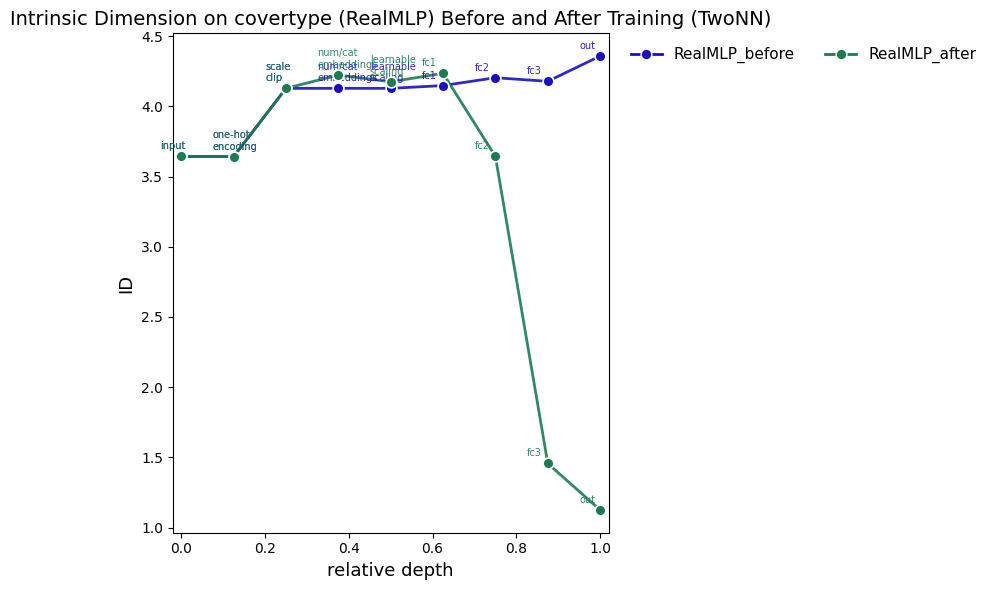

In [ ]:
evaluate_model_on_data(data_id=150,model_name="RealMLP",
                       opt_lr=1e-3,opt_wd=1e-4,num_classes=7)

### 4.1.3 Evaluation of **StandardMLP** on **Forest Covertype**

StandardMLP Statistics Fitted!
--- Starting Analysis for StandardMLP on covertype ---


Training epochs: 100%|██████████| 15/15 [00:40<00:00,  2.69s/it]


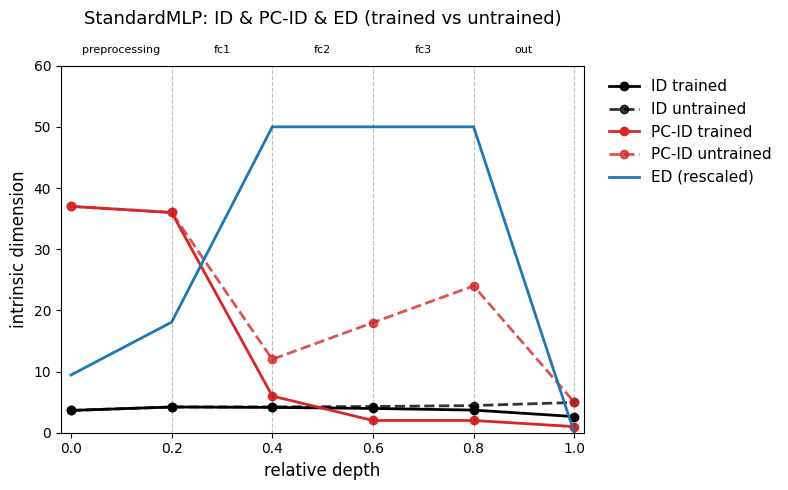

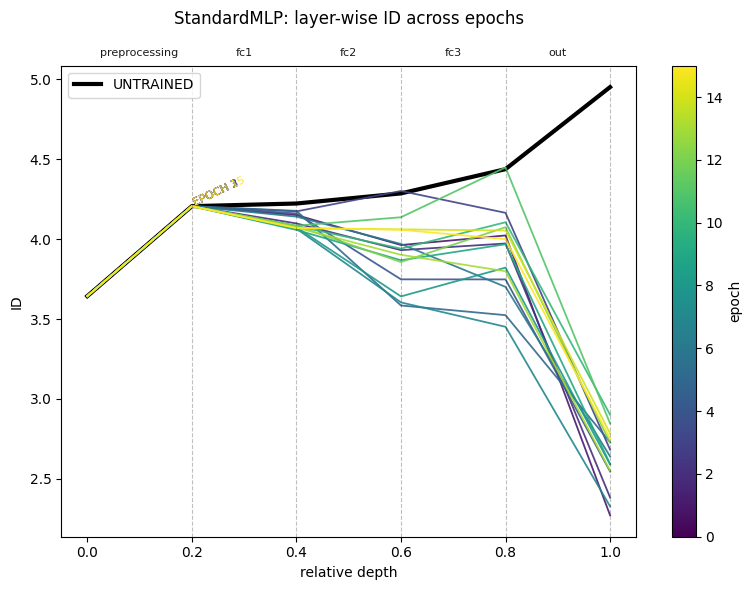

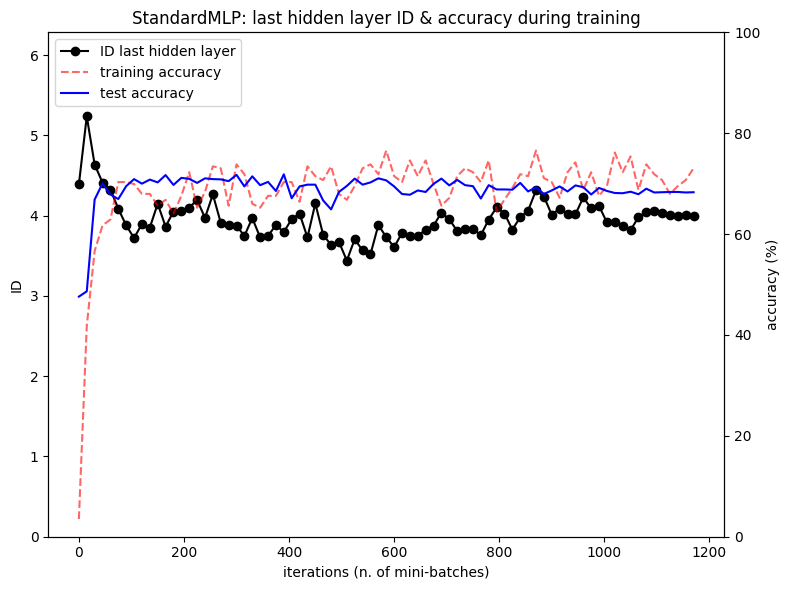

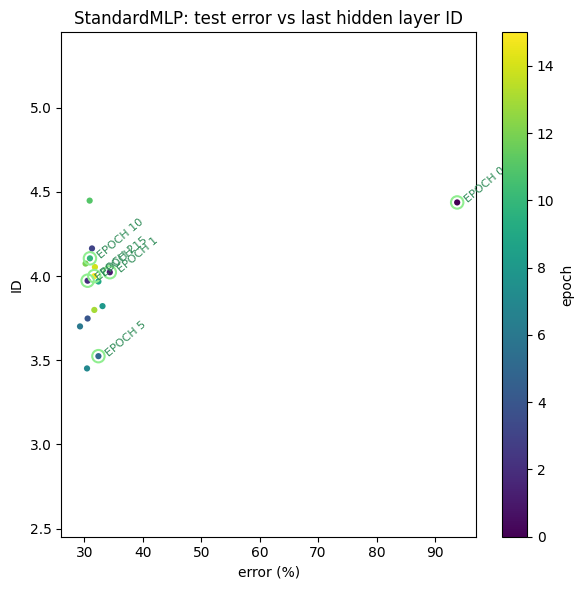

Models: 100%|██████████| 1/1 [00:00<00:00,  4.98it/s]


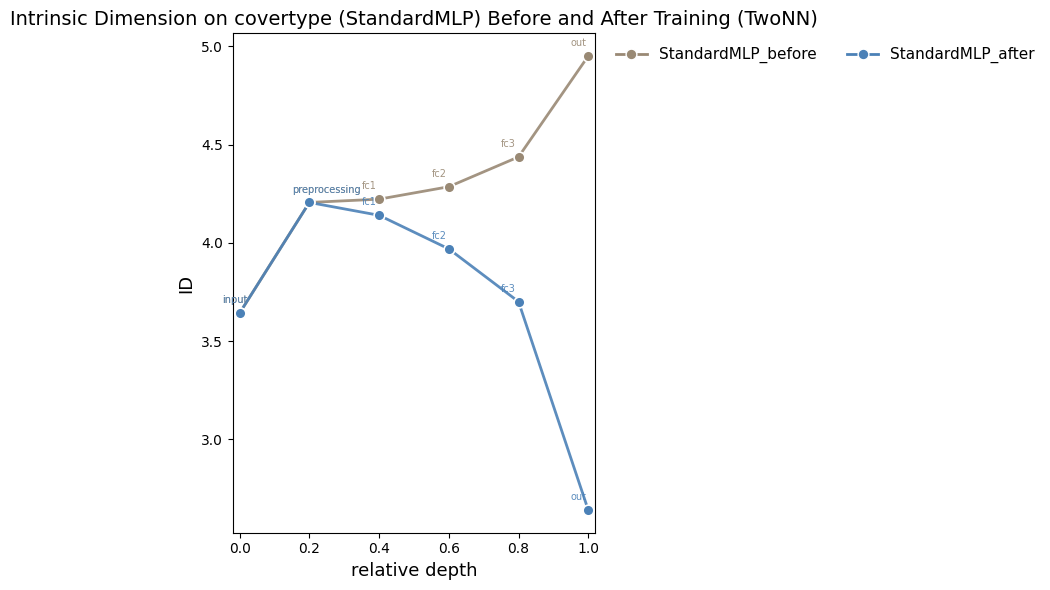

In [ ]:
evaluate_model_on_data(data_id=150,model_name="StandardMLP",
                       opt_lr=1e-2,opt_wd=1e-2,num_classes=7)

## 4.2 Experiment: Higgs Boson (Complex Dataset)

### 4.2.1 Evaluation of **TabM** on **Higgs Boson**

--- Starting Analysis for TabM on ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014 ---


Training epochs: 100%|██████████| 15/15 [01:03<00:00,  4.25s/it]


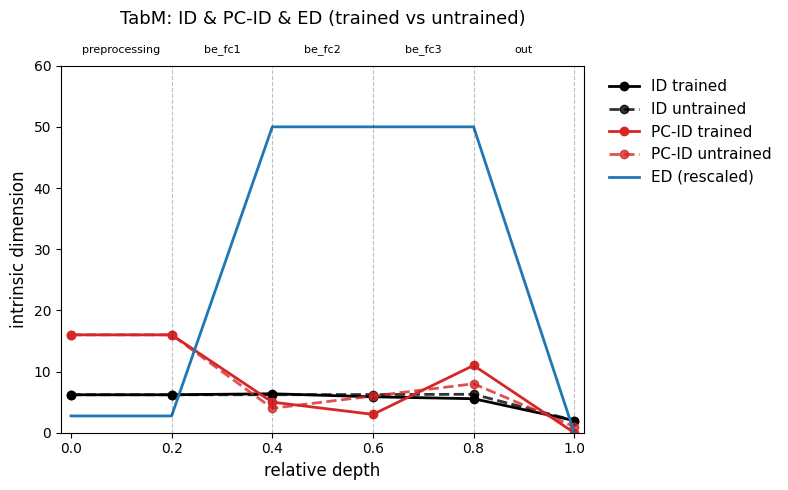

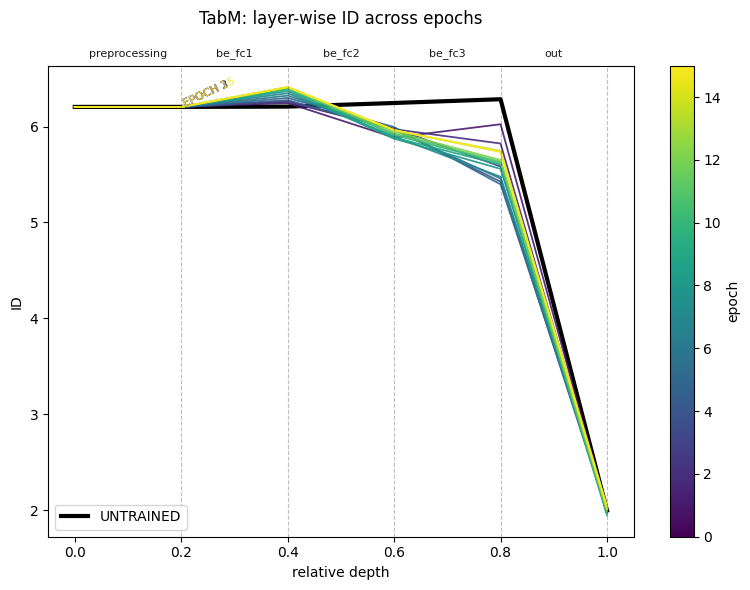

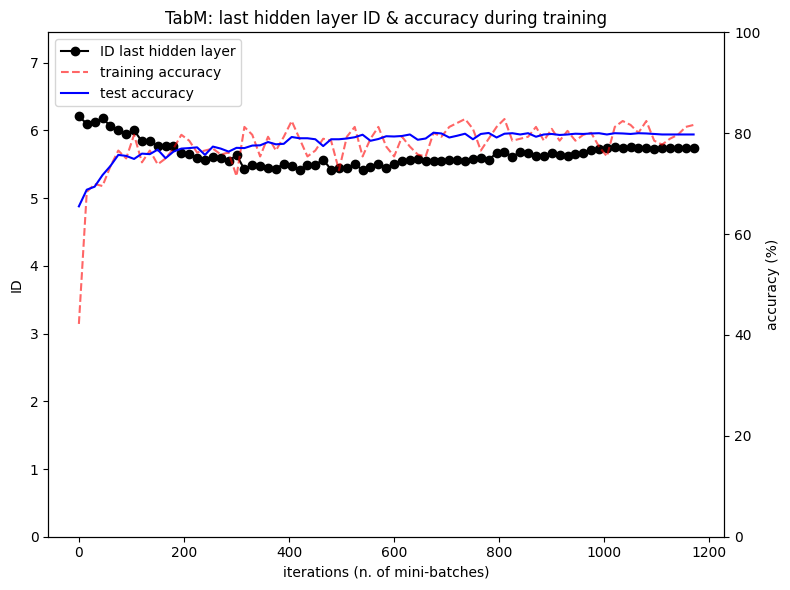

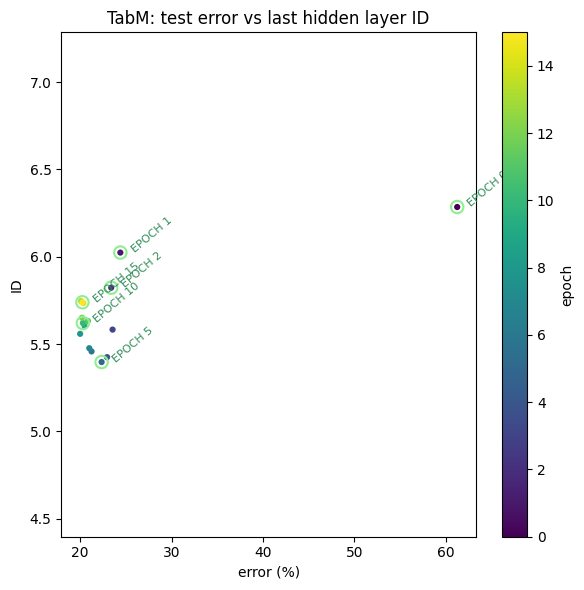

Models: 100%|██████████| 1/1 [00:01<00:00,  1.31s/it]


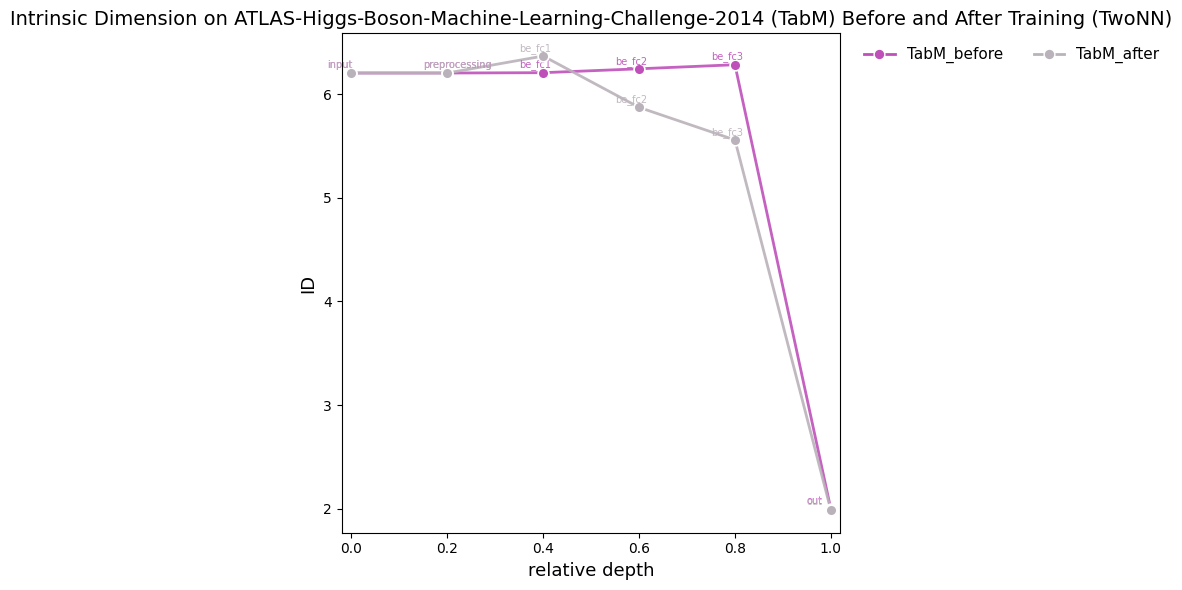

In [ ]:
evaluate_model_on_data(data_id=45551,model_name="TabM",
                       opt_lr=1e-3,opt_wd=1e-4,num_classes=2,k=4)

### 4.2.2 Evaluation of **RealMLP** on **Higgs Boson**

RealMLP statistics fitted.
--- Starting Analysis for RealMLP on ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014 ---


Training epochs: 100%|██████████| 15/15 [00:23<00:00,  1.55s/it]


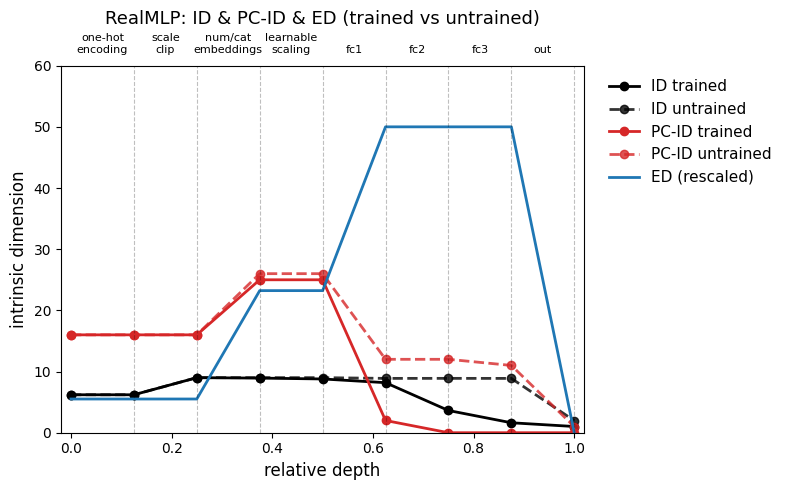

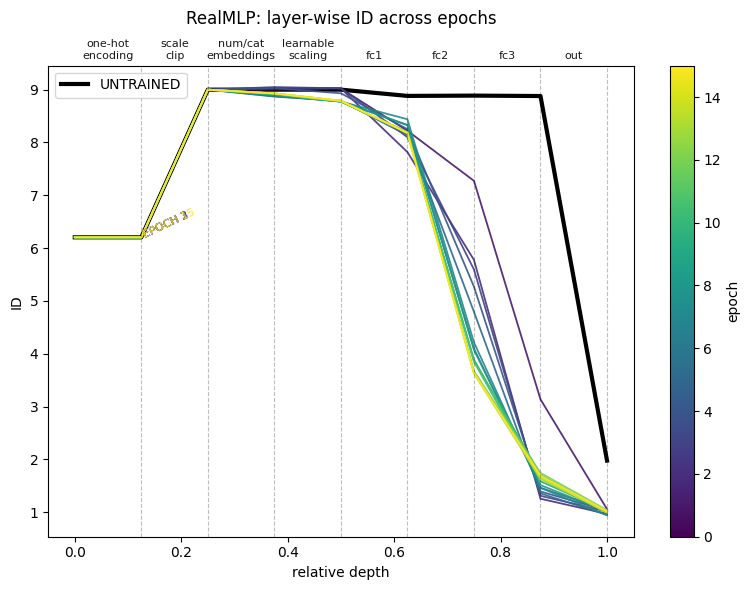

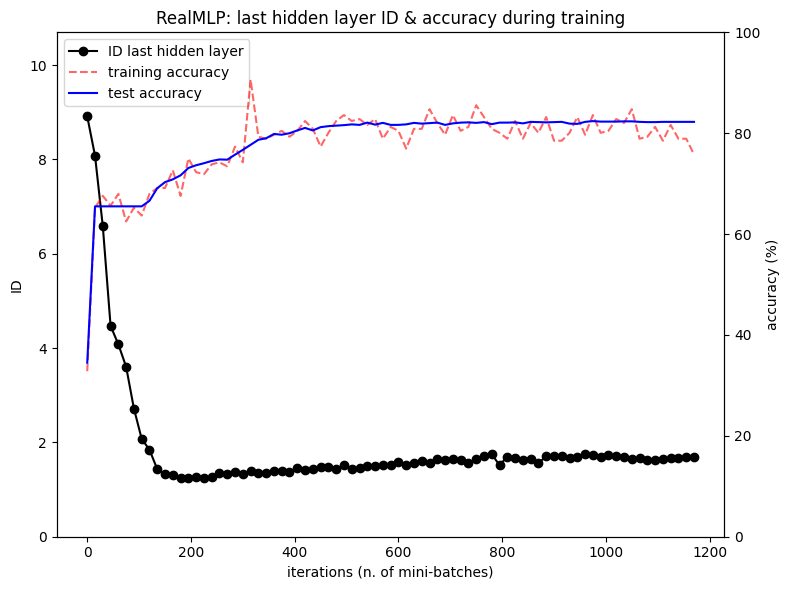

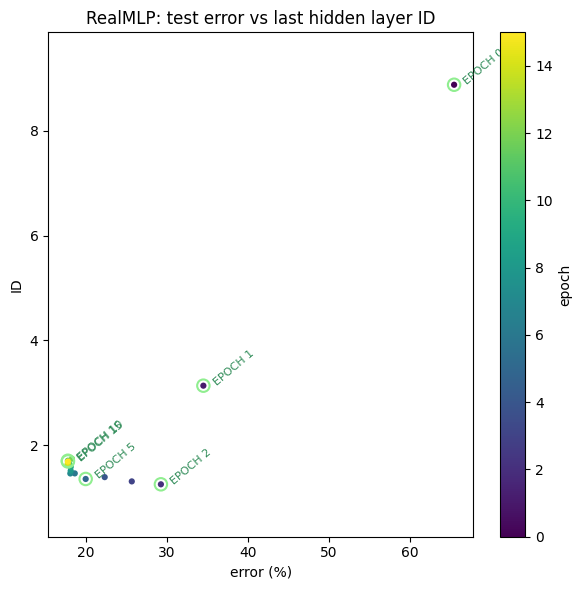

Models: 100%|██████████| 1/1 [00:00<00:00,  5.30it/s]


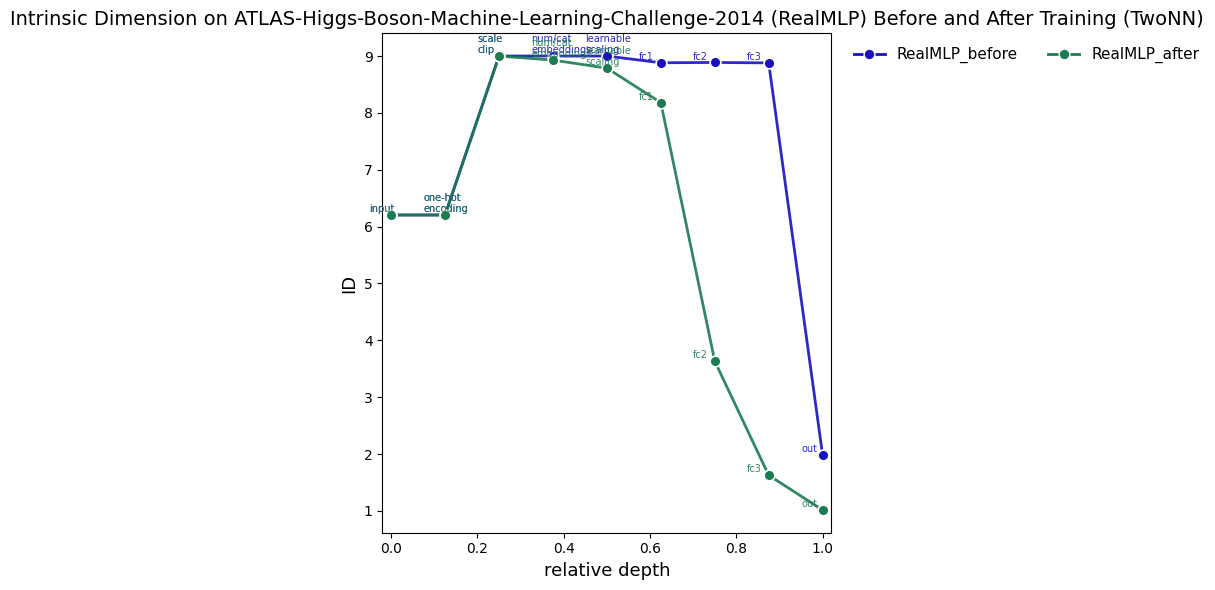

In [ ]:
evaluate_model_on_data(data_id=45551,model_name="RealMLP",
                       opt_lr=1e-3,opt_wd=1e-4,num_classes=2)

### 4.2.3 Evaluation of **StandardMLP** on **Higgs Boson**

StandardMLP Statistics Fitted!
--- Starting Analysis for StandardMLP on ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014 ---


Training epochs: 100%|██████████| 15/15 [00:17<00:00,  1.17s/it]


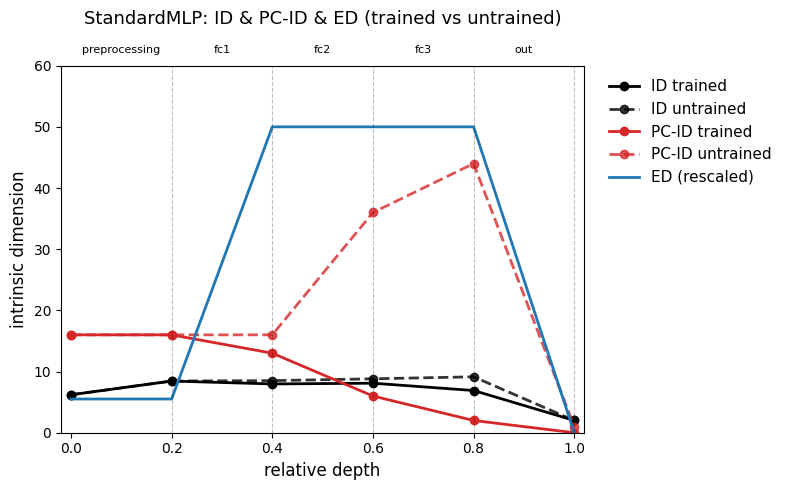

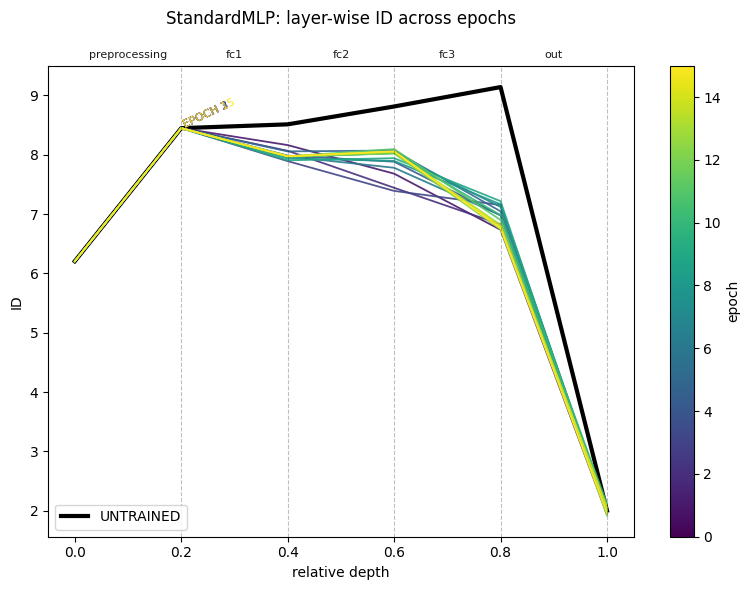

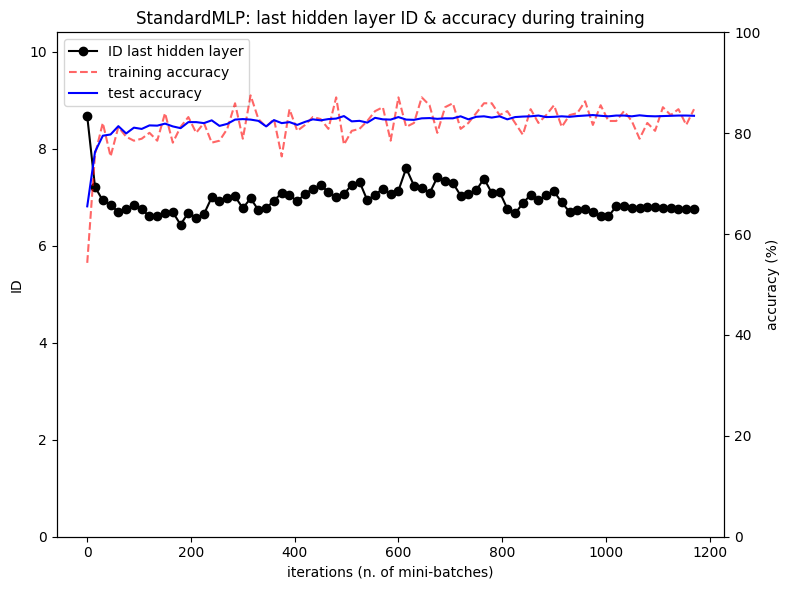

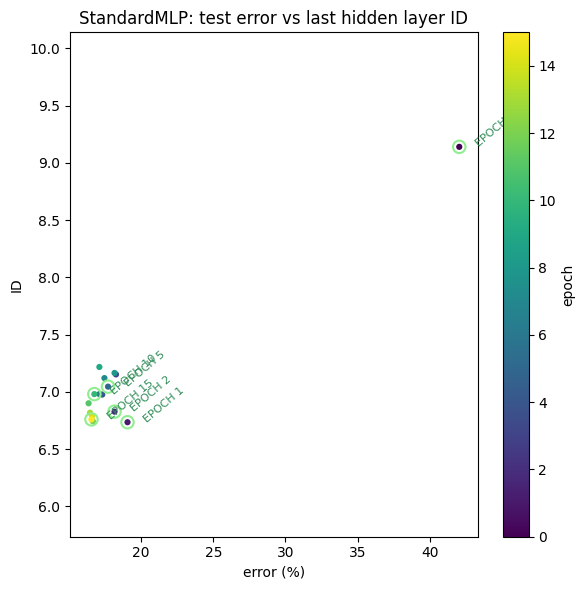

Models: 100%|██████████| 1/1 [00:00<00:00,  5.37it/s]


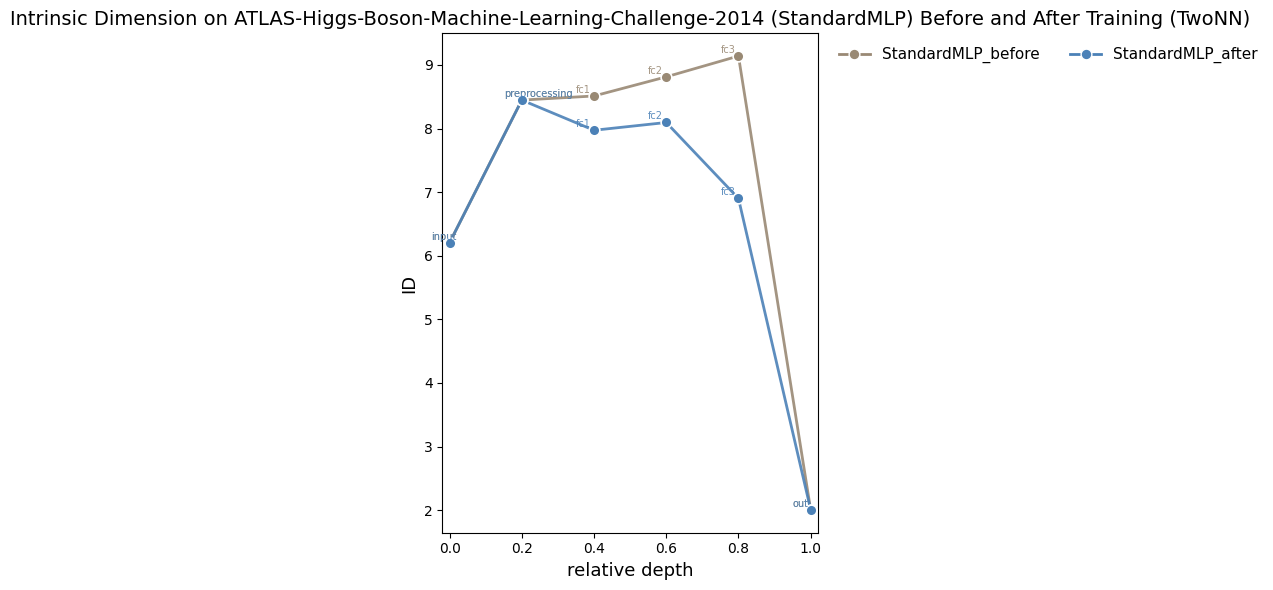

In [ ]:
evaluate_model_on_data(data_id=45551,model_name="StandardMLP",
                       opt_lr=1e-2,opt_wd=1e-2,num_classes=2)

## 4.3 Experiment: California Housing (Regression)

### 4.3.1 Evaluation of **TabM** on **California Housing**

--- Starting Analysis for TabM on california_housing ---


Training epochs: 100%|██████████| 15/15 [00:24<00:00,  1.66s/it]


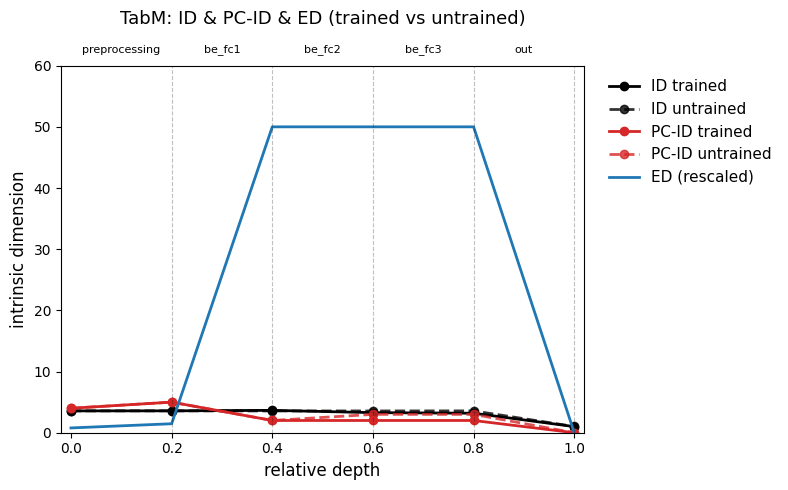

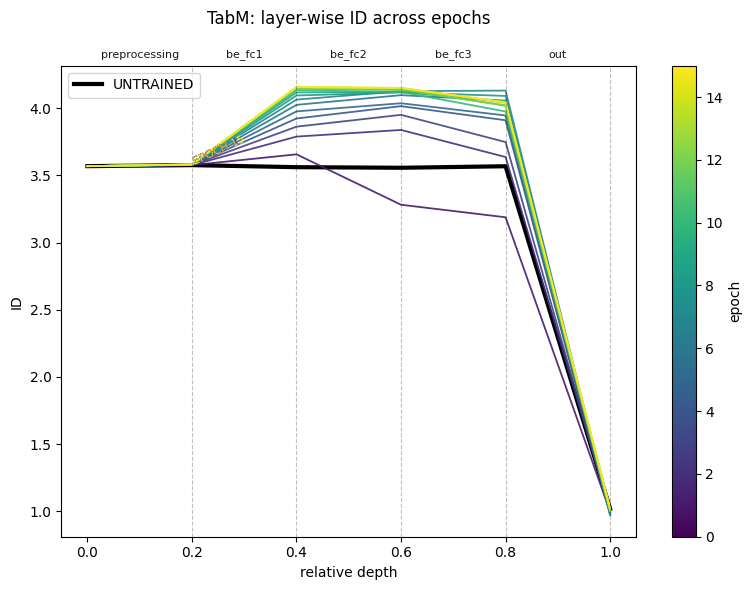

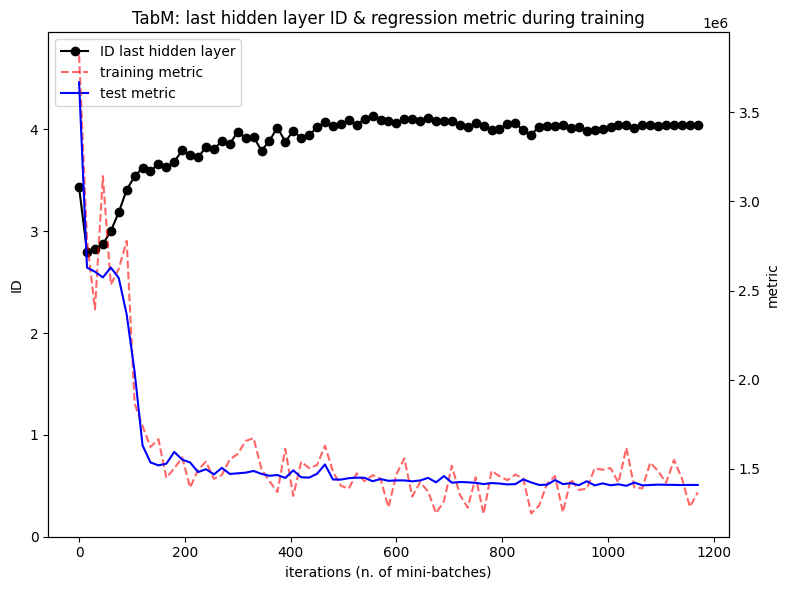

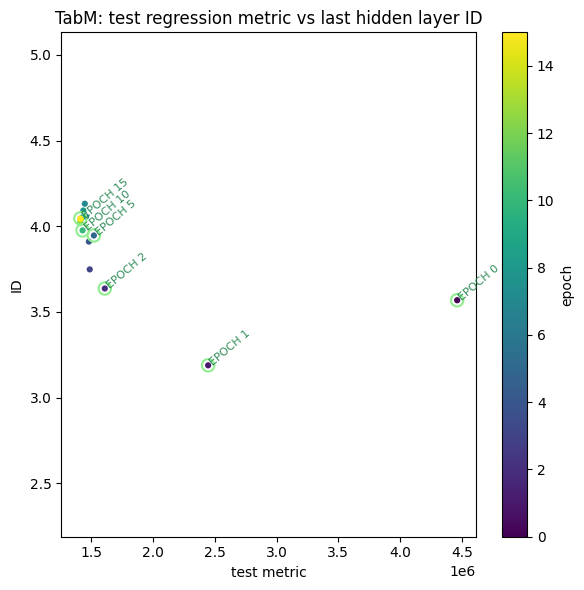

Models: 100%|██████████| 1/1 [00:00<00:00,  3.28it/s]


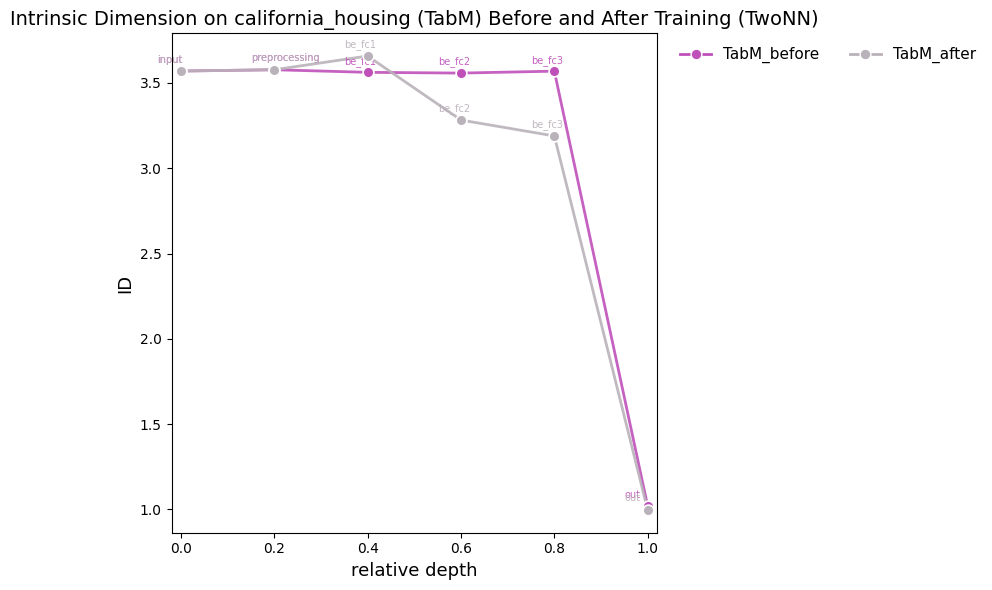

In [17]:
evaluate_model_on_data(data_id=43939,model_name="TabM",
                       opt_lr=1e-3,opt_wd=1e-4,k=6)

### 4.3.2 Evaluation of **RealMLP** on **California Housing**

RealMLP statistics fitted.
--- Starting Analysis for RealMLP on california_housing ---


Training epochs: 100%|██████████| 15/15 [00:15<00:00,  1.02s/it]


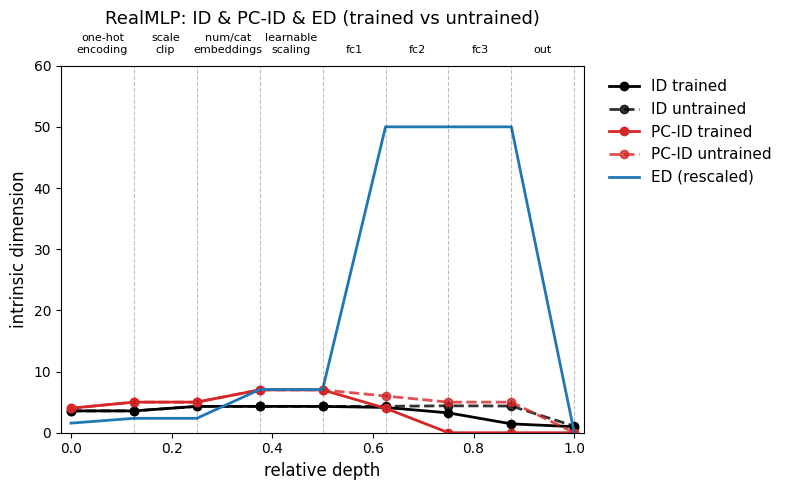

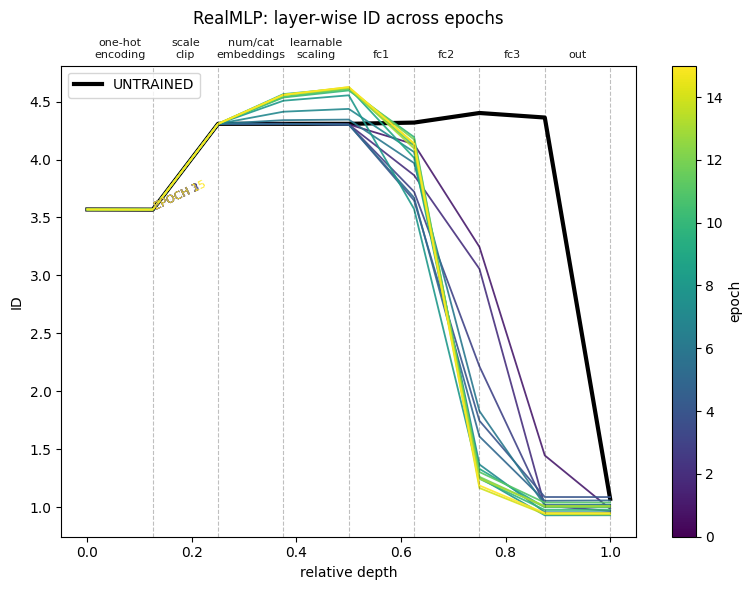

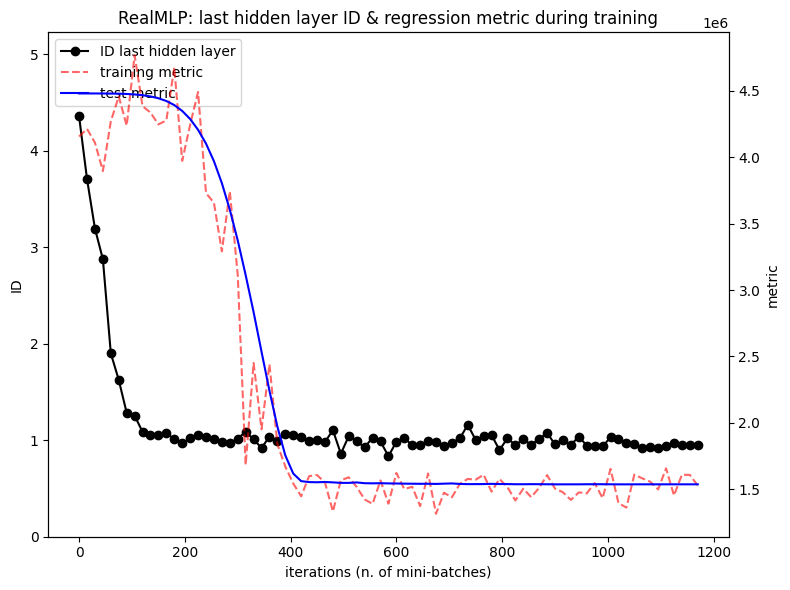

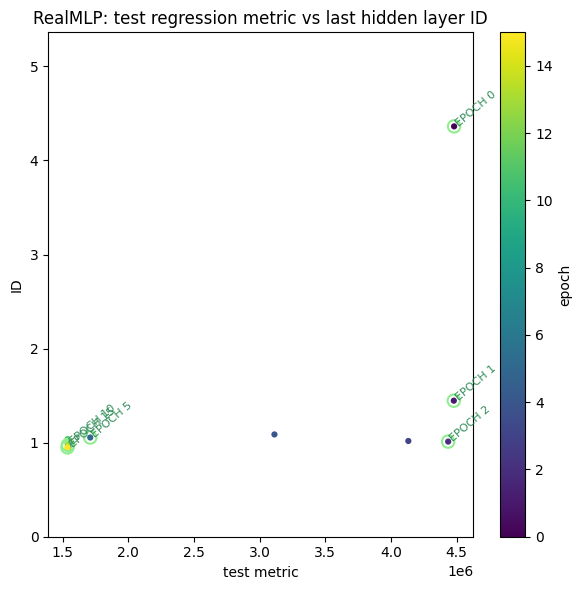

Models: 100%|██████████| 1/1 [00:00<00:00, 19.31it/s]


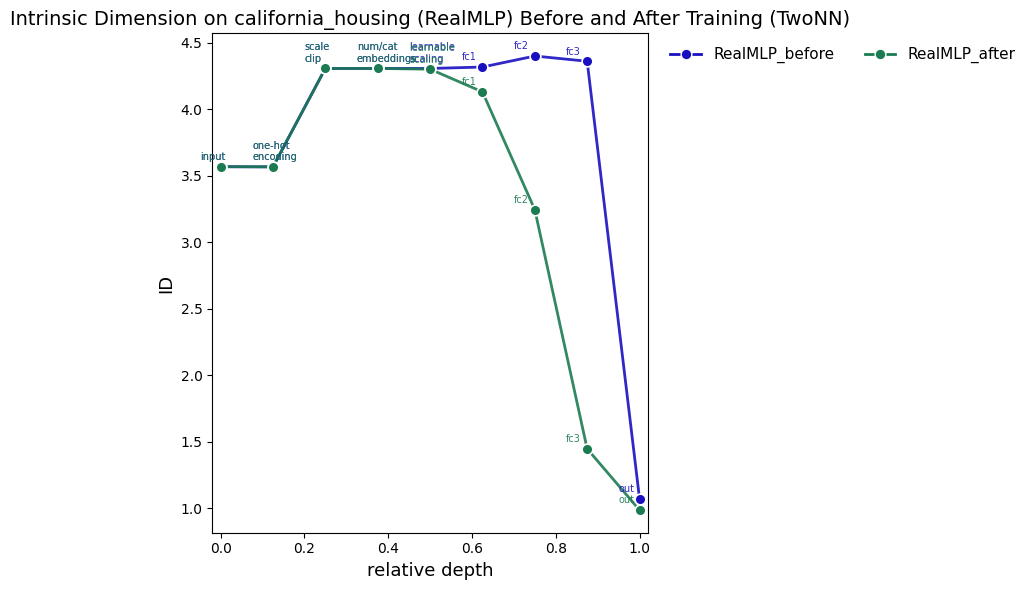

In [15]:
evaluate_model_on_data(data_id=43939,model_name="RealMLP",
                       opt_lr=1e-3,opt_wd=1e-4)

### 4.3.3 Evaluation of **StandardMLP** on **California Housing**

StandardMLP Statistics Fitted!
--- Starting Analysis for StandardMLP on california_housing ---


Training epochs: 100%|██████████| 15/15 [00:11<00:00,  1.28it/s]


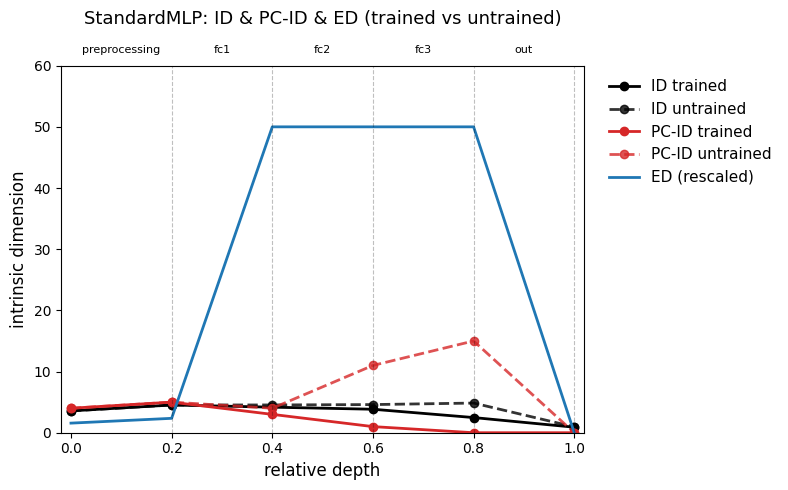

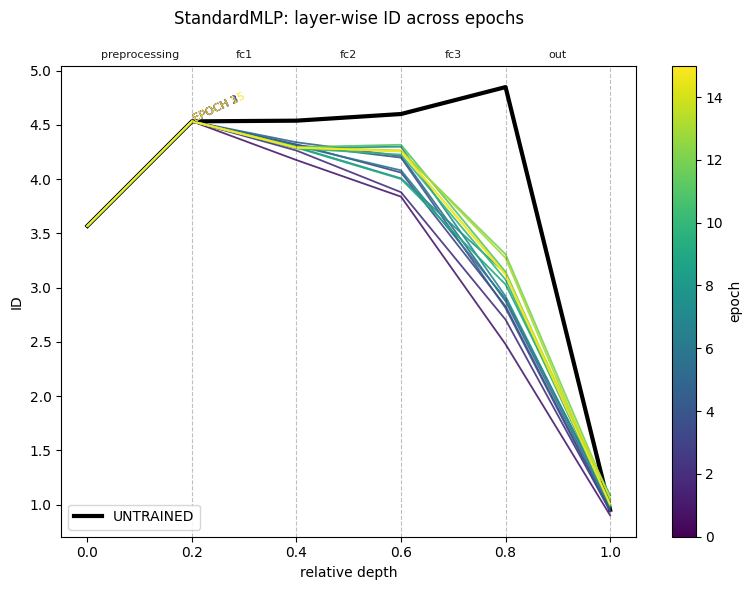

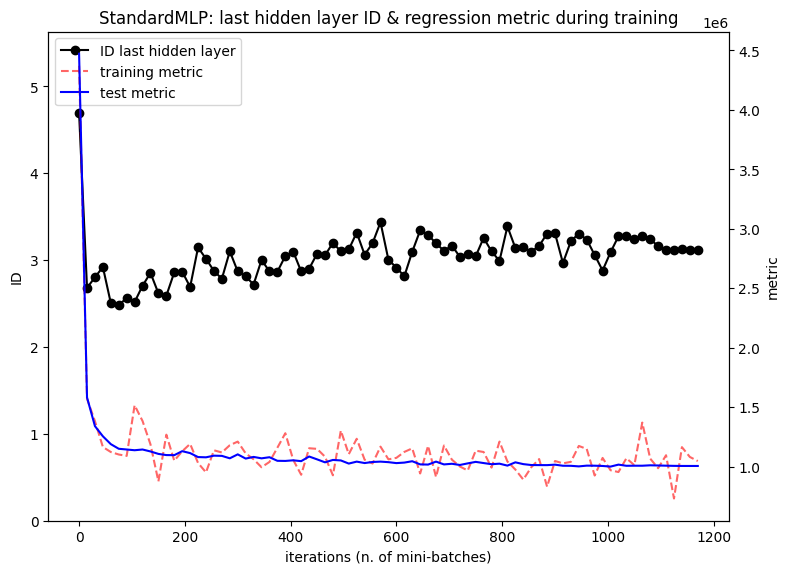

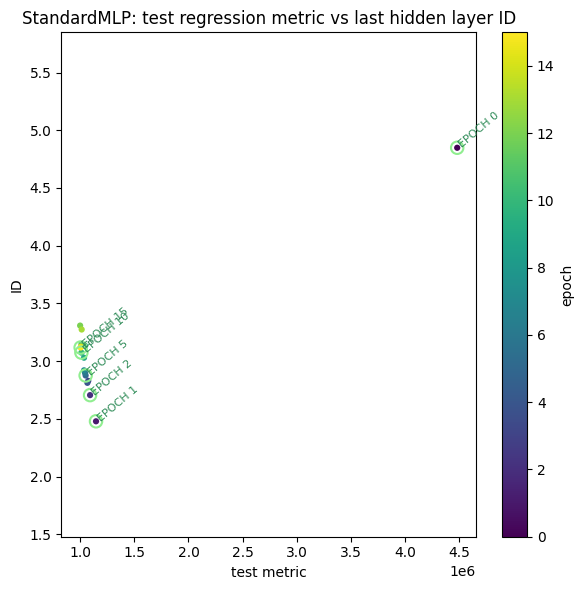

Models: 100%|██████████| 1/1 [00:00<00:00, 23.40it/s]


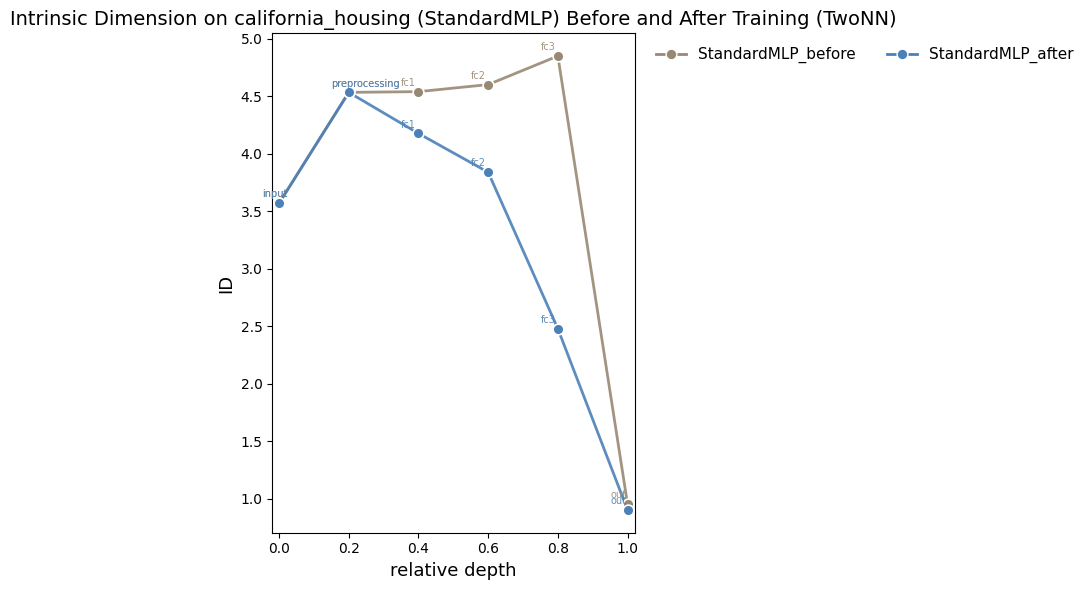

In [16]:
evaluate_model_on_data(data_id=43939,model_name="StandardMLP",
                       opt_lr=1e-2,opt_wd=1e-2)

# 5. Experimental Analysis Report

## Phenomenological Contrast

* CNN (image data): typically exhibit a "Low-High-Low" hunchback-shaped trajectory in their Intrinsic Dimension.

* MLP (Tabular Data):
    * Untrained Models: The ID curve remains flat across the early and middle layers, it only drops/increases at the final stage to a magnitude close to the number of classes. Throughout the process, the ID remains at a very low level (< 10).
    * During training, the model exhibits a global trend of dimensionality reduction. While minor transient expansions (e.g., ID rising slightly by 1-2 dimensions) may be observed in some datasets to resolve local non-linearities.

## Analysis of ID Dynamics: CNN vs. MLP

* The hunchback shape in CNNs stems from the process of Hierarchical Feature Construction. To distinguish between complex classes (e.g., Cat vs. Dog), the network must construct high-level semantics from low-level pixels. This necessitates an increase in dimensionality (ID expansion) to accommodate the newly created features. Mathematically, a higher-dimensional space can facilitate the disentangling of complex feature interactions via non-linear transformations, effectively "unfolding" the curled image manifold.

* In contrast, for MLPs on tabular data, we hypothesize that the results may relate to data characteristics and preprocessing mechanisms:

    * Semantic Density: Tabular inputs (e.g., "Age", "Amount") are already highly abstract semantic features. Unlike pixels, they do not require multiple layers of convolution to extract meaning.
    * Embedding Effect: We utilized Embedding layers to handle high-cardinality features. The training of embeddings maps discrete data into a ower-dimensional learned subspace before it even enters the linear layers.
    * Preprocessing Dominance: In tabular pipelines, the early stages primarily consist of deterministic preprocessing operations (e.g., one-hot encoding, robust scaling, smooth clipping), which are either non-parametric or fixed after statistics estimation. As a result, the intrinsic geometry of the data remains invariant across these stages during training. Consequently, meaningful ID dynamics only emerge once the representation enters trainable components, such as embedding layers or the MLP backbone.
    * Structural Invariance: We initially hypothesized that the uniform structure (e.g., all hidden dimensions set to 256) might have caused the flat dynamics. However, experiments with more flexible architectures showed no significant difference. The ID demonstrates a robust invariance to architectural width, rather than evolving into a hunchback shape.

## Analysis of ID Dynamics: Before vs. After Training

* **Before Training (Passive Propagation):** The weight matrices are randomly initialized. At this stage, the network has not yet "learned" to distinguish between signal and noise. It primarily reflects random projection effects rather than task-driven shaping. Notably, the behavior at the final layer is structurally determined by the task definition. In binary classification (e.g., Higgs), the Intrinsic Dimension (ID) drops at the end largely due to the output layer's dimension (2 classes) creates a physical bottleneck smaller than the propagating manifold's dimension. Conversely, in multi-class settings (e.g., Covertype with 7 classes), where the output dimension exceeds the manifold's ID, this structural bottleneck is absent. Consequently, the trajectory remains flat—or even exhibits slight stochastic expansion—right up to the logits, suggesting that the untrained network acts without active compression.

* **After Training (Feature Filtering):** During training, the model appears to discard non-task-relevant variation after the input layer. The subsequent gradual decline represents the refinement of the feature manifold, collapsing it onto a lower-dimensional discriminative subspace required for the classification task.
